# Fractional Brownian Motion Using Variance Ratio Tests

Consider a sample of $t$ measurements,

$
\begin{align}
X_0, X_1, X_2, \ldots, X_t
\end{align}
\tag{1}
$

A test is desired to determine if the series represents brownian motion, which is defined by,

$
\begin{align}
X_t = \sum_{i=1}^t X_i - X_{i-1} = \sum_{i=1}^t \Delta X_{i}
\end{align}
\tag{2}
$

where $\Delta X_i$ are independent and identically distributed with distribution,

$
\begin{align}
\Delta X_i \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{3}
$

and

$
\begin{align}
\text{Cov}(\Delta X_i \Delta X_j) = \sigma^2 \delta_{ij}
\end{align}
\tag{4}
$

This is the homoscedasticity assumption. Consider the difference,

$
\begin{align}
\Delta X_i(s) = X_i - X_{i+s}
\end{align}
\tag{5}
$

So that,

$
\begin{align}
X_t = \sum_{i=1}^n \Delta X_i(s)
\end{align}
\tag{6}
$

with $t=ns$. Let, 

$
\begin{align}
\sigma^2(s) = \text{Var}\left(\Delta X_i (s) \right)
\end{align}
\tag{7}
$

Recall for brownian motion $\sigma_B^2(t) = \sigma^2t$, it follows that $\sigma^2_B(s) = \sigma^2(1)s$. Consider the ratio,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
\tag{8}
$

where,

$
\begin{align}
&\sigma^2(1) = \frac{1}{t-1} \sum_{i=1}^t \left(X_i - X_{i-1} - \mu \right) \\
&\mu = \frac{1}{t} \left( X_t - X_0 \right)
\end{align}
\tag{9}
$

In Lo and Mackinlay, 1988, "Stock market Prices do not Follow Random Walks" it was shown that an unbiased estimator of $\sigma^2(s)$ is given by,

$
\begin{align}
\sigma^2(s) = \frac{1}{m} \sum_{i=s}^t \left( X_t - X_{t-s} - s\mu \right)^2
\end{align}
\tag{10}
$

where,

$
\begin{align}
m = \left(t - s + 1 \right) \left( 1 - \frac{s}{t} \right)
\end{align}
\tag{11}
$

If $X_t$ is brownian motion, $\sigma^2(s) = \sigma^2(1)$, $s = \sigma^2_B(s)$. It follows that $\text{VR}(s) = 1$. A test statistic for this condition is given by,

$
\begin{align}
Z(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta(s)}}
\end{align}
\tag{12}
$

where,

$
\begin{align}
\theta(s) = \frac{2\left( 2s - 1 \right)\left( s - 1 \right)}{3st}
\end{align}
\tag{13}
$

and $Z(s) \sim \text{Normal}(0,1)$. This test-statistic was derived assuming homoscedasticity which implies that the random component is independent of $s$. If instead the random component varies with $s$ heteroscedasticity is assumed.

For this case the test-statistic is given by,

$
\begin{align}
Z^\ast(s) = \frac{\text{VR}(s) - 1}{\sqrt{\theta^\ast (s)}}
\end{align}
\tag{14}
$

where,

$
\begin{align}
&\theta^\ast (s) = \sum_{j=1}^{s-1} \left[ \frac{2\left( s - j \right) } {s} \right]^2 \hat{\delta}(j) \\
&\hat{\delta}(j) = \frac{\sum_{i=j+1}^t \left( X_i - X_{i-1} - \mu \right)^2 \left( X_{i-j} - X_{i-j-1} - \mu \right)^2}{\left[ \sum_{i=1}^t \left( X_i - X_{i-1} - \mu \right)^2 \right]^2}
\end{align}
\tag{15}
$

The significance test using $Z(s)$ and $Z^\ast(s)$ succeeds if the time series is brownian motion. This test is implemented using two tails and the series is brownian motion if it succeeds. A test for $H<0.5$ uses a lower tail test and succeeds if the test for brownian motion fails. Similarly, A test for $H>0.5$ would use an upper tail test and succeed if the test for brownian motion fails.

## Import

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats, HypothesisTestType
from lib.plots import fpoints, comparison, curve, variance_ratio_test, PlotType
from lib.utils import create_parameter_scan, apply_to_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def create(H_vals, npts):
    params = [{"H": H, "npts": npts} for H in H_vals]
    source = lambda **kwargs: fbm.create_fft_source(**kwargs)
    return create_parameter_scan(source, *params)

def lag_var_plot(samples, H, npts):
    title = f"Simulated FBM Lagged Variance: H={H}"
    labels = [r"$\sigma^2(s)$", r"$s^{2H}$"]
    s_vals, lag_var = stats.compute_lag_var(samples, smax=npts/10, npts=100)
    t, fbm_var = fbm.compute_var(numpy.array(s_vals)[::5], H=H)
    fpoints(data=lag_var, func=fbm_var, x=s_vals, fx=t, plot_axis_type=PlotType.LOG, title=title, labels=labels, xlabel=r"$s$", ylabel=r"$\sigma^2(s)$")

def vr_plot(samples, H, npts):
    title = f"Simulated FBM Variance Ratio: H={H}"
    labels = [r"VR$(s)$", r"$s^{2H-1}$"]
    s_vals, vr = fbm.compute_vr_scan(samples, smax=npts/10, npts=100)
    t, fbm_vr = fbm.compute_vr(numpy.array(s_vals)[::5], H=H)
    fpoints(data=vr, func=fbm_vr, x=s_vals, fx=t, title=title, labels=labels, plot_axis_type=PlotType.LOG, xlabel=r"$s$", ylabel=r"VR$(s)$")
    
def homo_test_stat_plot(report, H):
    title = f"Homoscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)

def hetero_test_stat_plot(report, H):
    title = f"Heteroscedastic Variance Ratio Test: H={H}"
    variance_ratio_test(report, title=title)
    
def H_labels(H_vals):
    return [f"H={format(H, '1.2f')}" for H in H_vals]

## $\sigma^2 (s)$ and $\text{VR}(s)$ Verification

The $\sigma^2 (s)$ calculation is verified by comparing with $s^{2H}$. The variance ratio is given by,

$
\begin{align}
\text{VR}(s) = \frac{\sigma^2(s)}{\sigma_B^2(s)}
\end{align}
$

Since $\sigma^2(s) \sim s^{2H}$ and $\sigma_B^2(s) \sim s$ it follows that $\text{VR}(s) \sim s^{2H - 1}$.

In [3]:
npts = 2**16
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

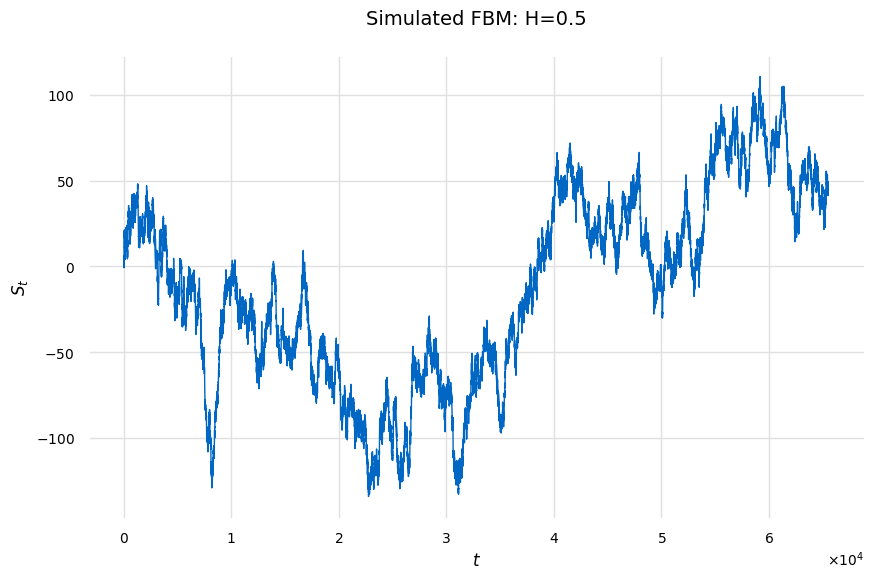

In [4]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

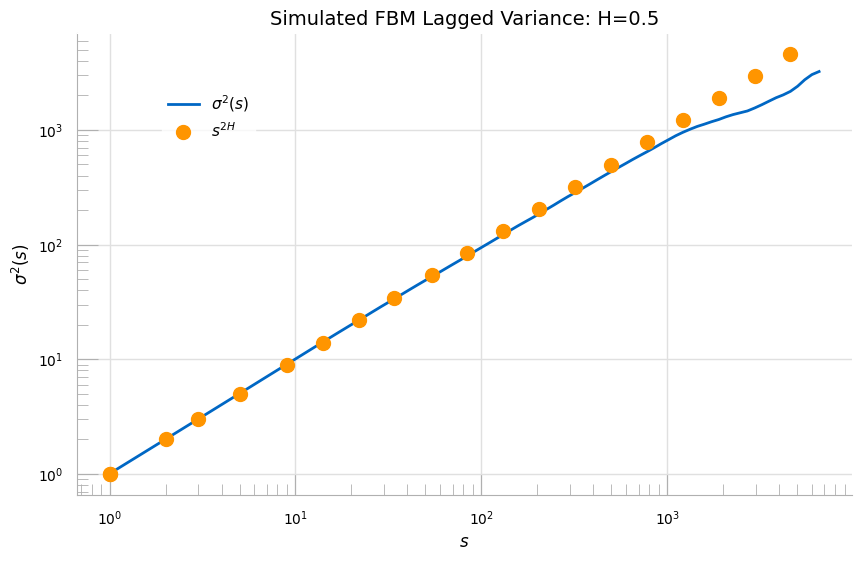

In [5]:
lag_var_plot(samples[0], H_vals[0], npts)

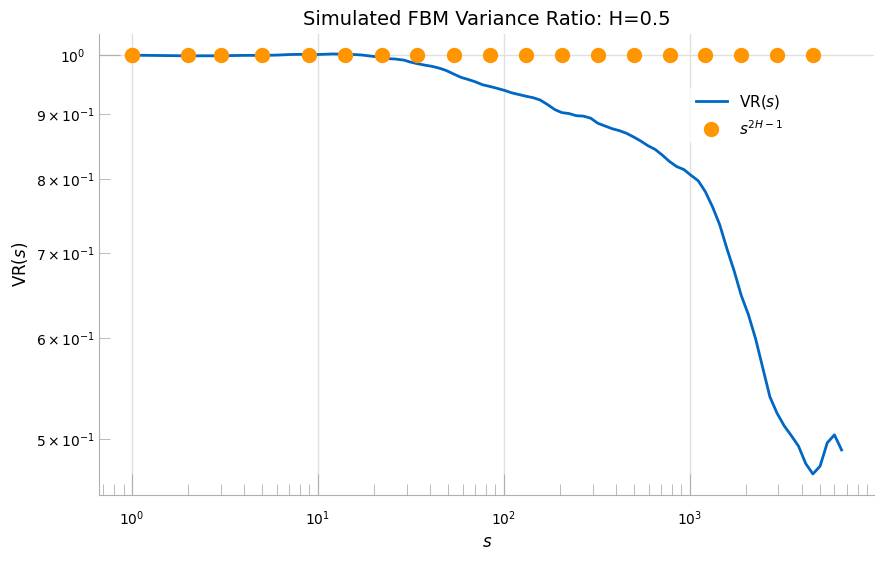

In [6]:
vr_plot(samples[0], H_vals[0], npts)

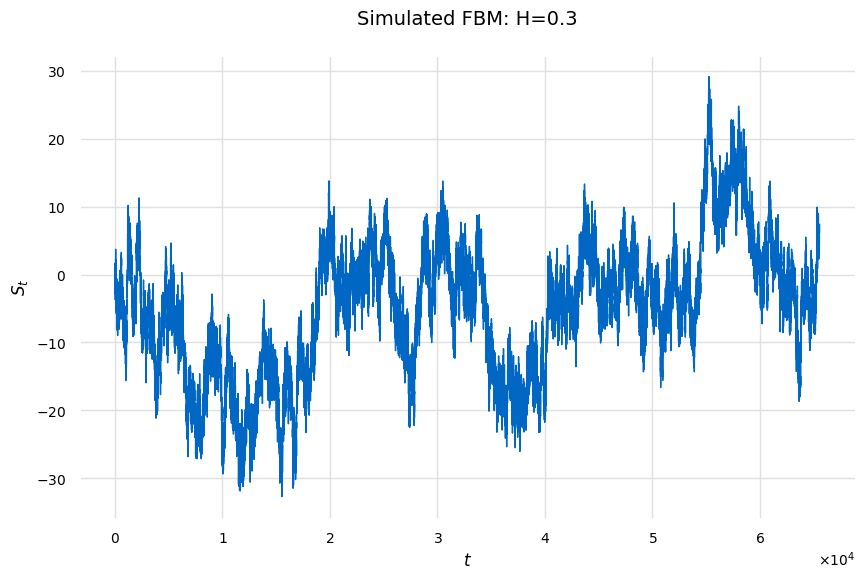

In [7]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

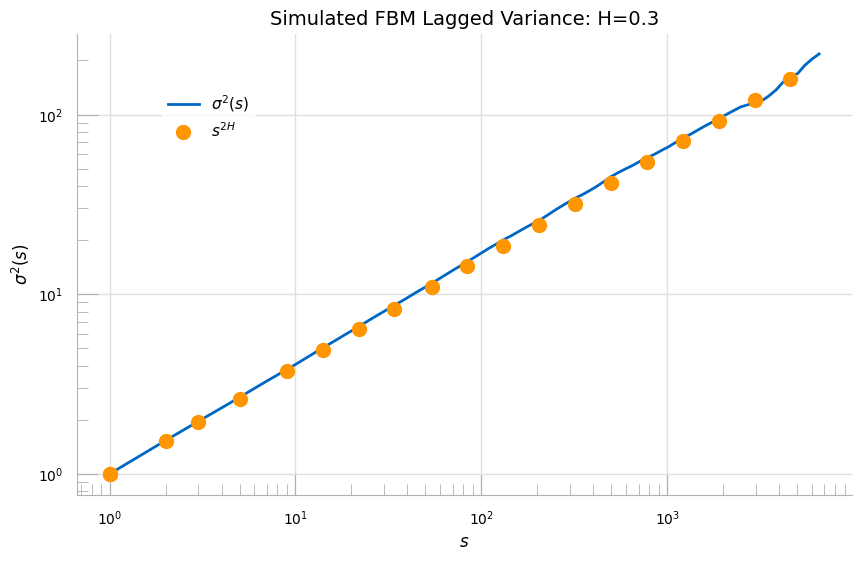

In [8]:
lag_var_plot(samples[1], H_vals[1], npts)

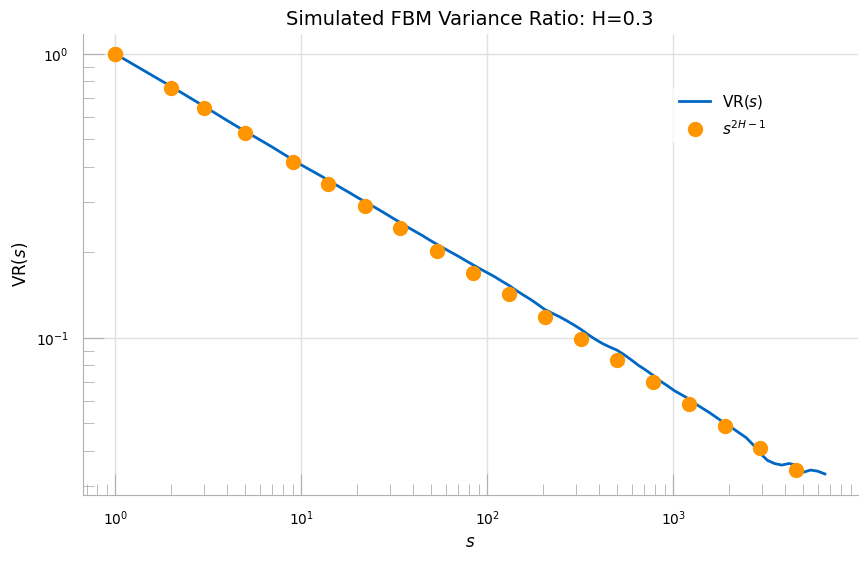

In [9]:
vr_plot(samples[1], H_vals[1], npts)

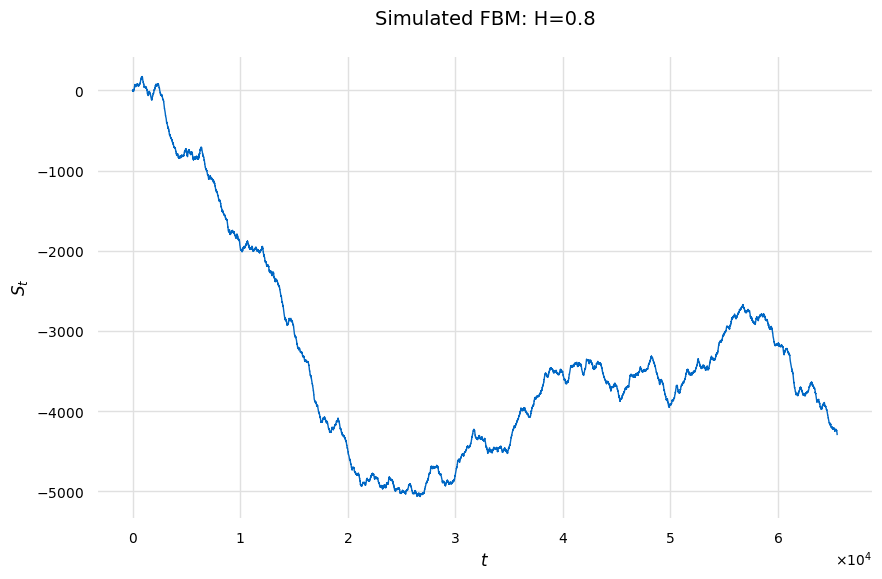

In [10]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

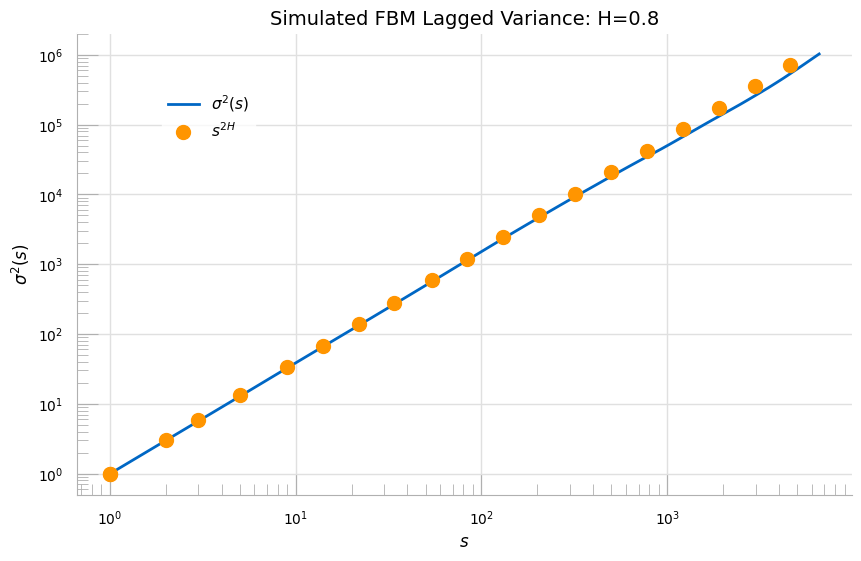

In [11]:
lag_var_plot(samples[2], H_vals[2], npts)

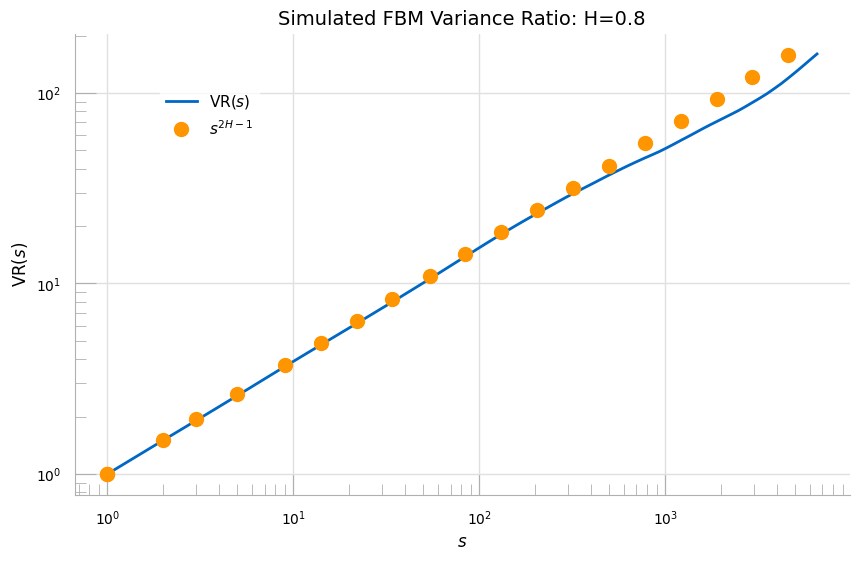

In [12]:
vr_plot(samples[2], H_vals[2], npts)

## Small Sample Size

In the previous verification section a rather large sample size was used to provide enough data to compute accurate averages. In general</br>
this is not practical. here more realistic sample sizes are used to see the impact on the analysis. 

In [13]:
npts = 2**9
H_vals = [0.5, 0.3, 0.8]
t, samples = create(H_vals, npts)

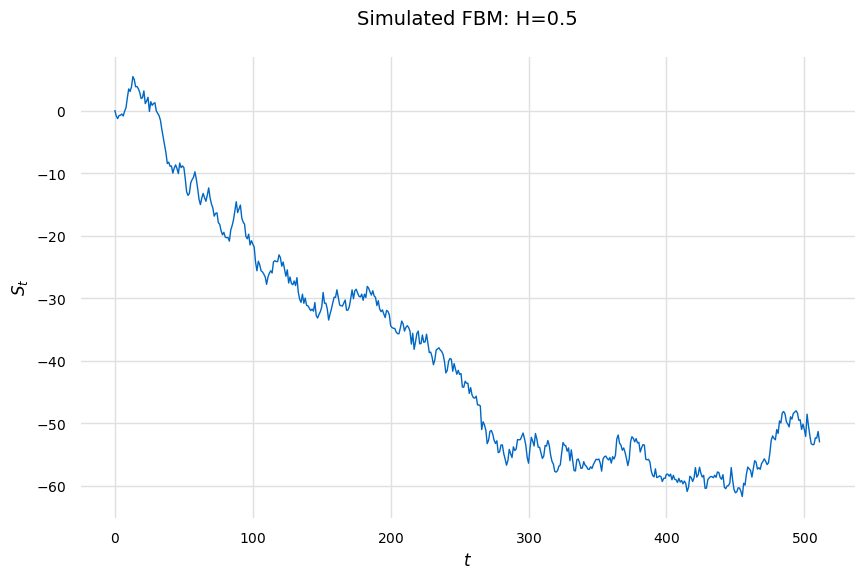

In [14]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

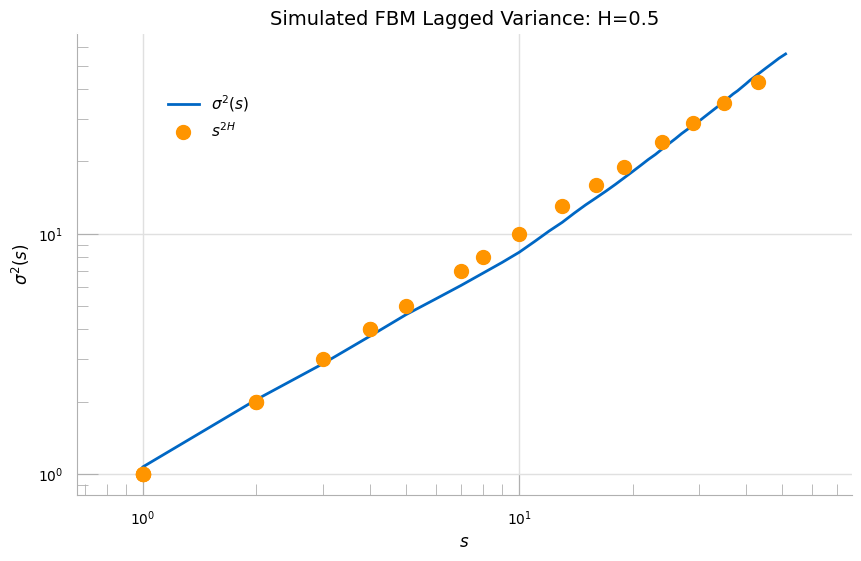

In [15]:
lag_var_plot(samples[0], H_vals[0], npts)

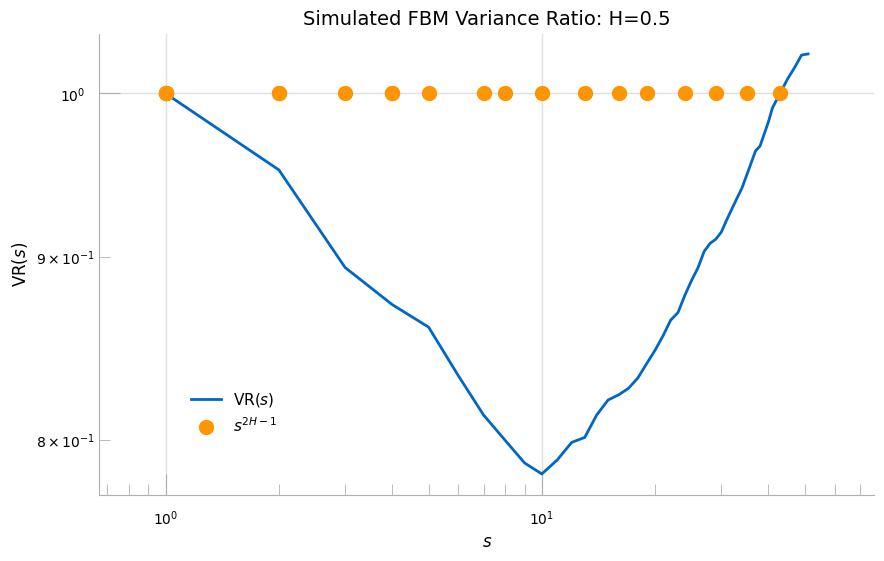

In [16]:
vr_plot(samples[0], H_vals[0], npts)

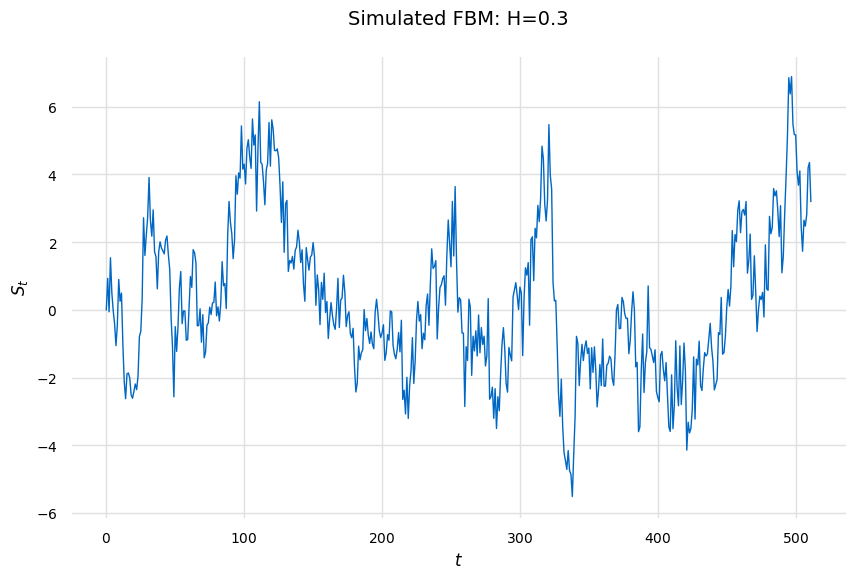

In [17]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

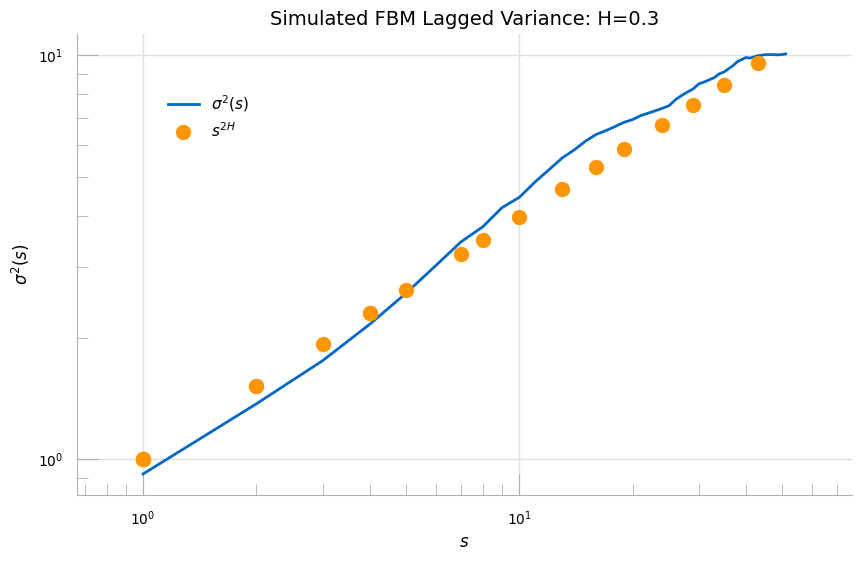

In [18]:
lag_var_plot(samples[1], H_vals[1], npts)

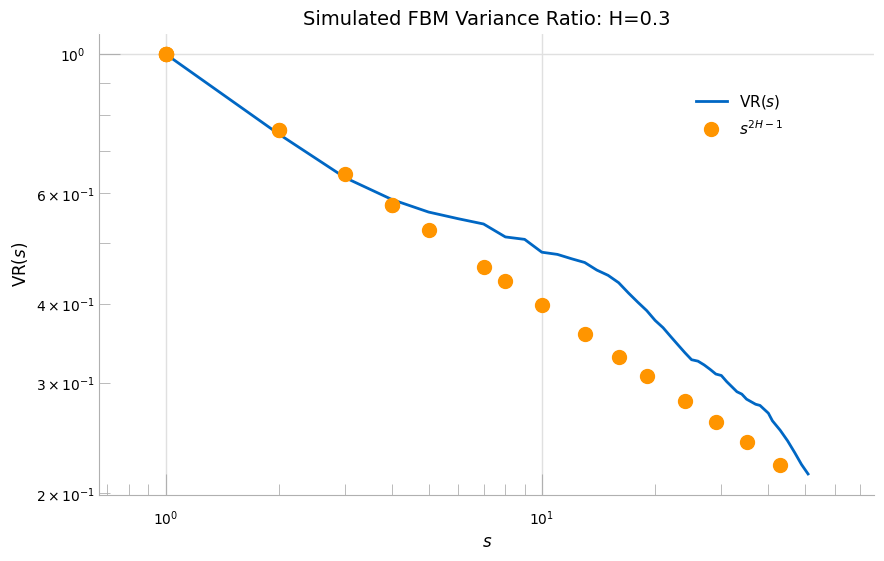

In [19]:
vr_plot(samples[1], H_vals[1], npts)

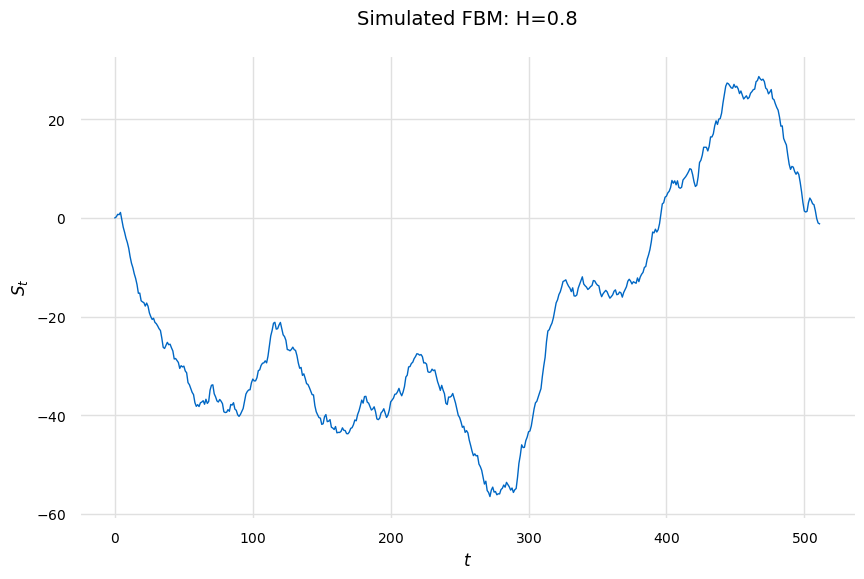

In [20]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

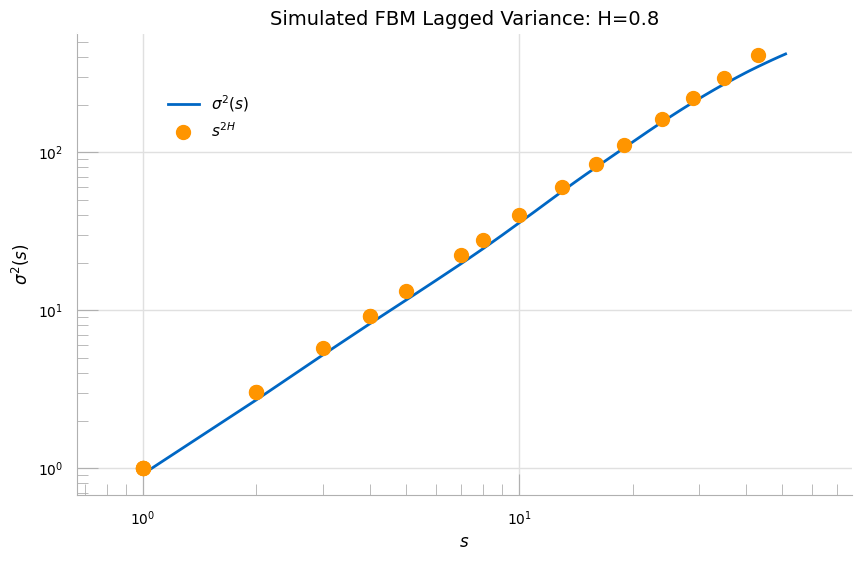

In [21]:
lag_var_plot(samples[2], H_vals[2], npts)

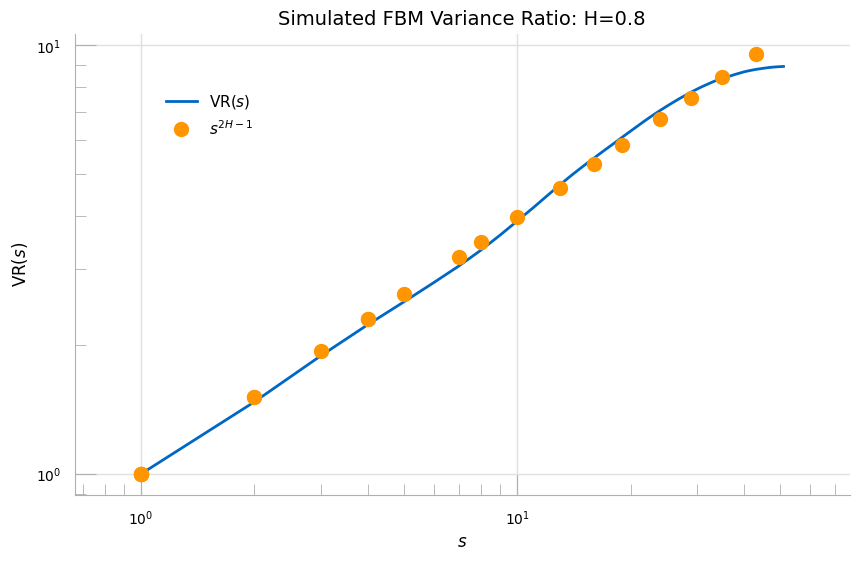

In [22]:
vr_plot(samples[2], H_vals[2], npts)

## Variance Ratio Test Comparison

In this section simulations that test the homoscedastic and heteroscedastic variance ratio test statistic are presented. It is seen that the results are not</br>
significantly different despite the greater cost of the heteroscedastic calculation. First large time series are</br>
analyzed followed by more realistic series lengths. A range of $H$ values is used.

In [23]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.5, 0.3, 0.7]
t, samples = create(H_vals, npts)

### H = 0.5 

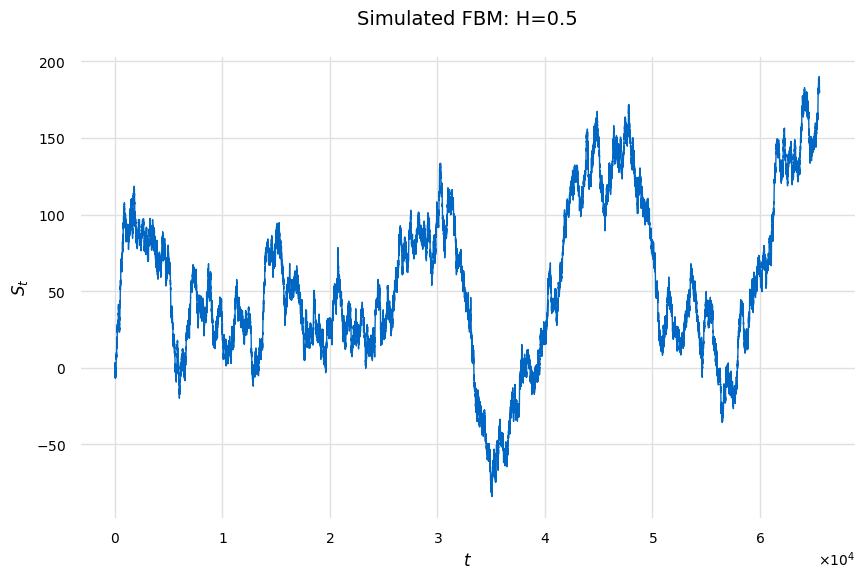

In [24]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [25]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.718 │    0.086 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.263 │    0.206 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.426 │    0.154 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.752 │    0.452 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [26]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "be475ef6-32bd-485c-ac7e-d8015d9bd932",
                "label": "$Z(s)$",
                "value": -1.718161116485007
            },
            "pval": {
                "test_id": "be475ef6-32bd-485c-ac7e-d8015d9bd932",
                "label": "$p-value$",
                "value": 0.08576723170033285
            },
            "params": [
                {
                    "test_id": "be475ef6-32bd-485c-ac7e-d8015d9bd932",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "be475ef6-32bd-485c-ac7e-d8015d9bd932",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "be475ef6-32bd-485c-ac7e-d8015d9bd932",
                "labe

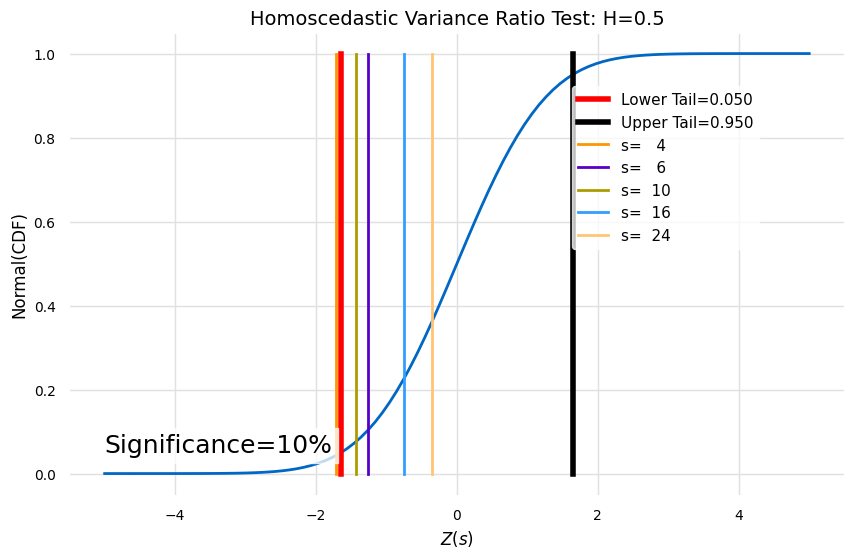

In [27]:
homo_test_stat_plot(result, H_vals[0])

In [28]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -1.721 │    0.085 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -1.263 │    0.206 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.425 │    0.154 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -0.751 │    0.453 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -0

In [29]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "52c26738-7e7e-4b1c-b037-1babb7a4fe9c",
                "label": "$Z(s)$",
                "value": -1.7208684269470582
            },
            "pval": {
                "test_id": "52c26738-7e7e-4b1c-b037-1babb7a4fe9c",
                "label": "$p-value$",
                "value": 0.08527470203572629
            },
            "params": [
                {
                    "test_id": "52c26738-7e7e-4b1c-b037-1babb7a4fe9c",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "52c26738-7e7e-4b1c-b037-1babb7a4fe9c",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "52c26738-7e7e-4b1c-b037-1babb7a4fe9c",
                "lab

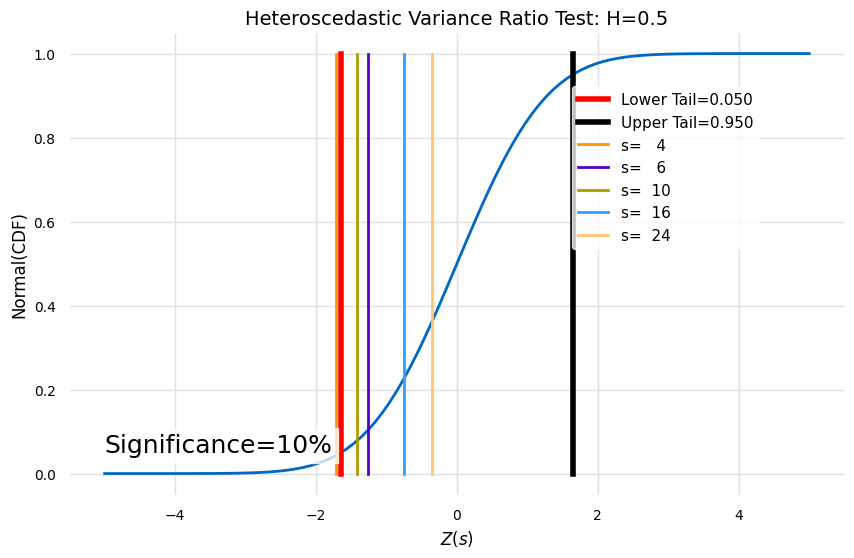

In [30]:
hetero_test_stat_plot(result, H_vals[0])

### H = 0.3

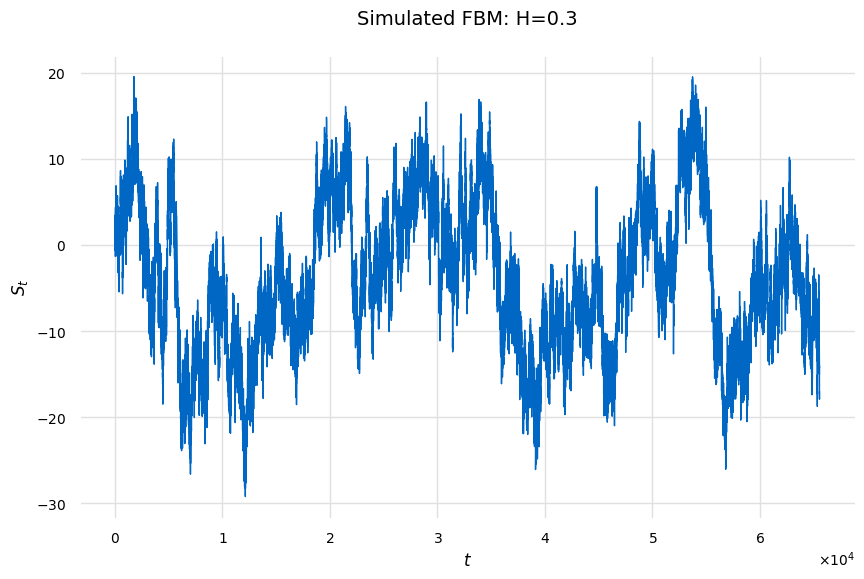

In [31]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [32]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -58.08  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -52.331 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -45.032 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.462 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

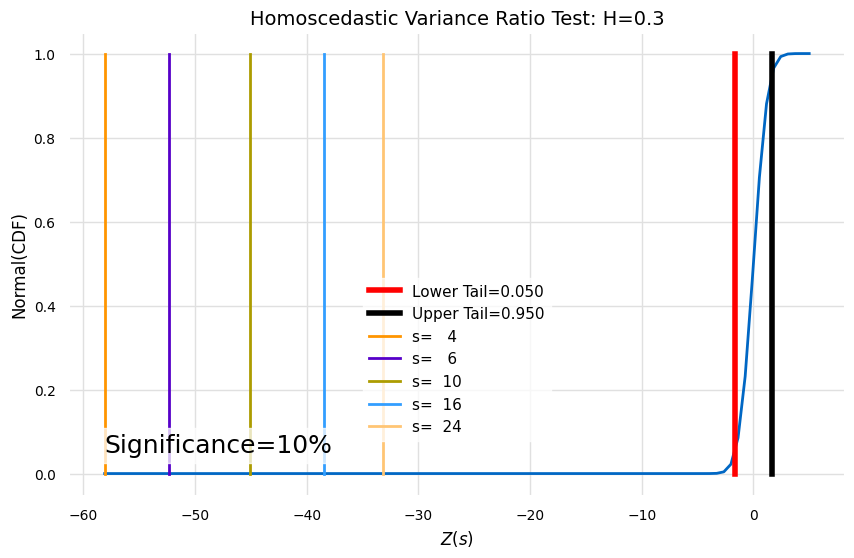

In [33]:
homo_test_stat_plot(result, H_vals[1])

In [34]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │ -55.852 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ -50.817 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ -44.185 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ -38.004 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

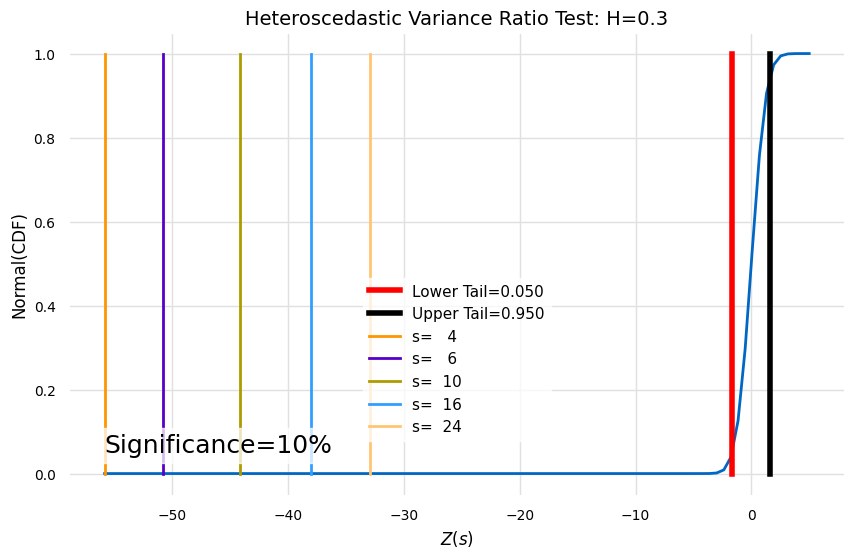

In [35]:
hetero_test_stat_plot(result, H_vals[1])

### H=0.7

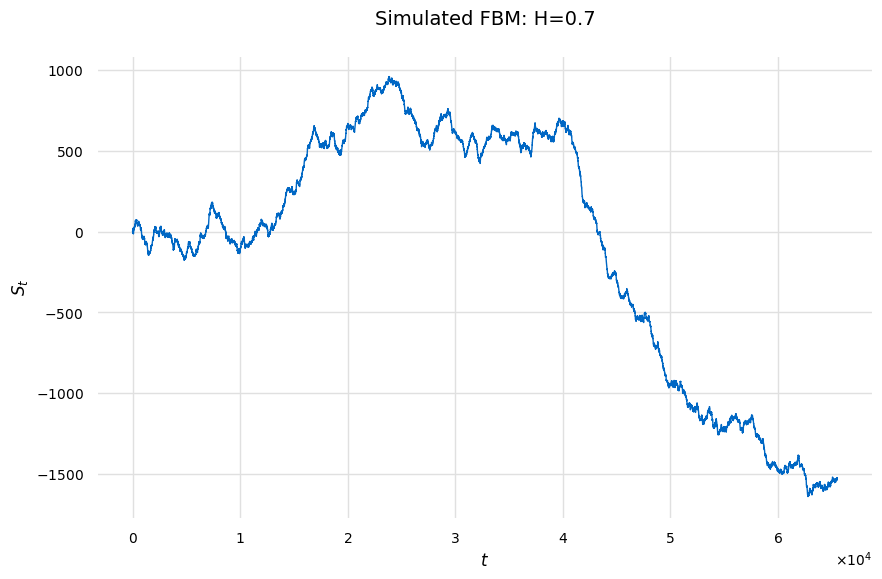

In [36]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [37]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  98.57  │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │ 105.175 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 111.014 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 113.849 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

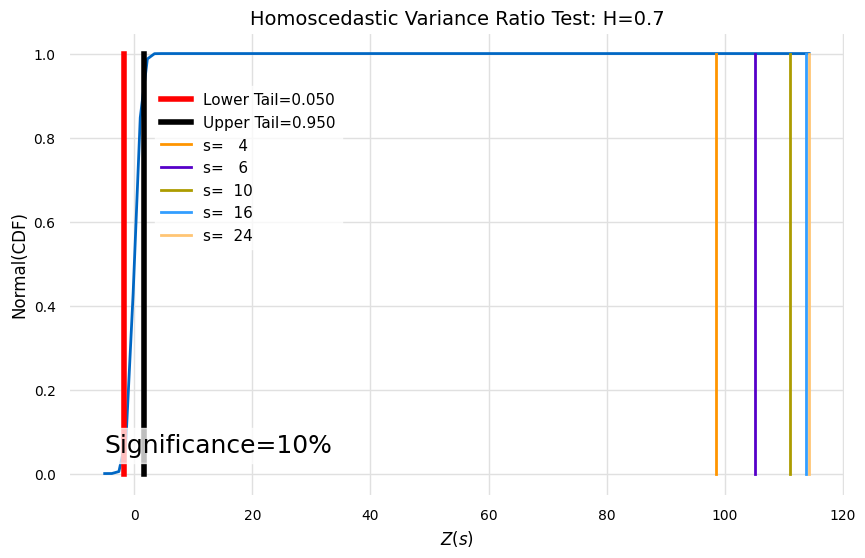

In [38]:
homo_test_stat_plot(result, H_vals[2])

In [39]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤═════════╤══════════╤══════════╕
│   s │    Z(s) │   pvalue │ Result   │
╞═════╪═════════╪══════════╪══════════╡
│   4 │  91.576 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│   6 │  99.127 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  10 │ 106.383 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤
│  16 │ 110.454 │        0 │ Failed   │
├─────┼─────────┼──────────┼──────────┤

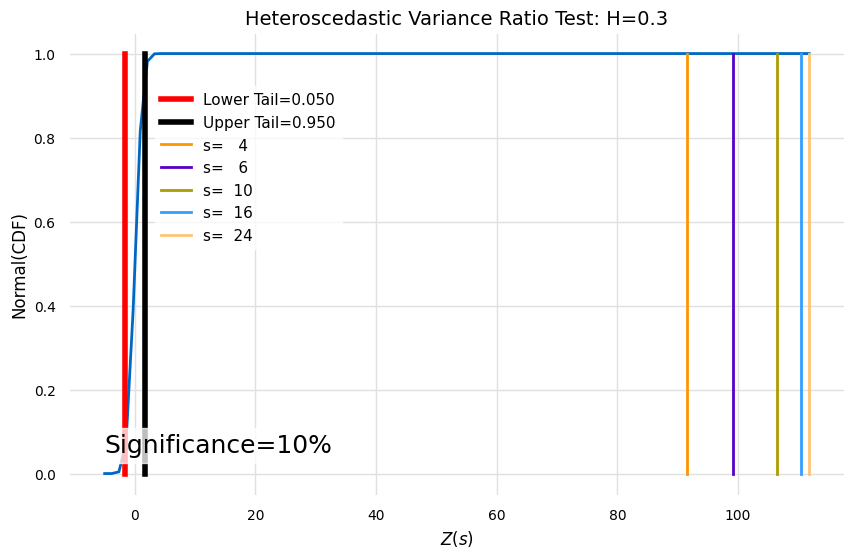

In [40]:
hetero_test_stat_plot(result, H_vals[1])

### Values Near H=0.5

The performance of the homoscedastic and heteroscedastic for values near $H=0.5$ is evaluated.

In [41]:
npts = 2**16
s_vals = [2, 10, 100, 1000]
H_vals = [0.475, 0.49, 0.51, 0.525]
t, samples = create(H_vals, npts)

#### H=0.51

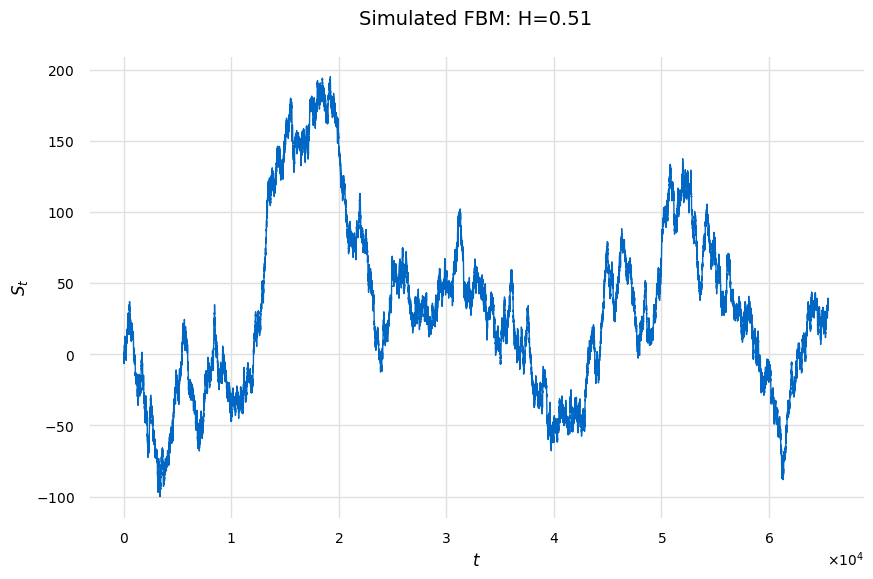

In [42]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [43]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  1.224 │    0.221 │ Passed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  2.018 │    0.044 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  1.127 │    0.26  │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  0.936 │    0.349 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

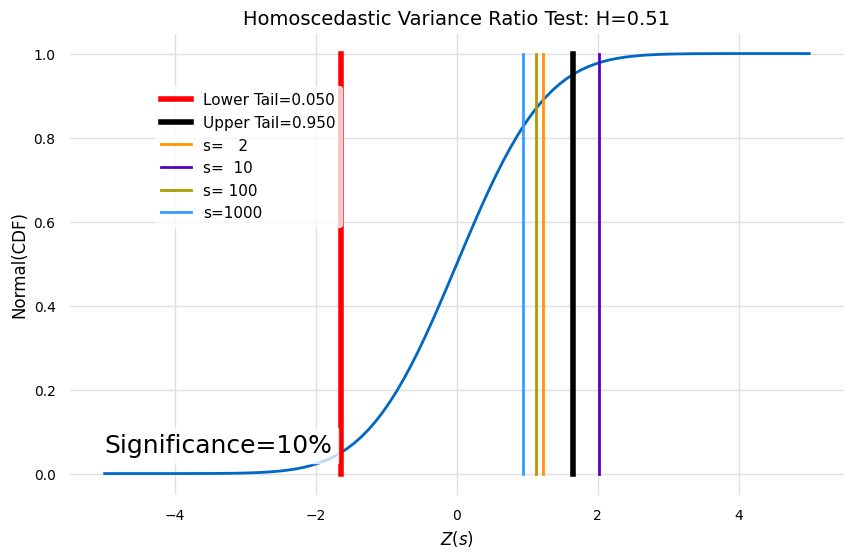

In [44]:
homo_test_stat_plot(result, H_vals[2])

In [45]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │  1.227 │    0.22  │ Passed   │
├──────┼────────┼──────────┼──────────┤
│   10 │  2.017 │    0.044 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │  1.127 │    0.26  │ Passed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │  0.937 │    0.349 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

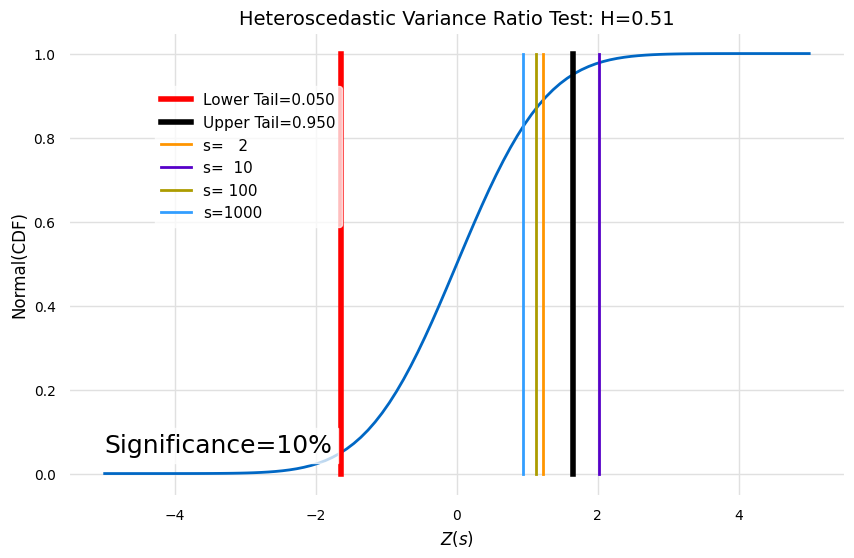

In [46]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.49

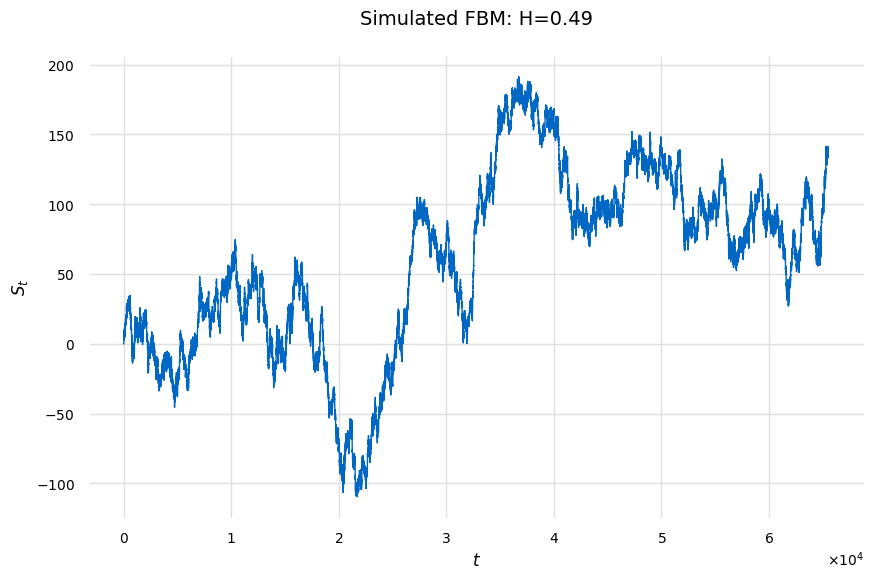

In [47]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [48]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -2.8   │    0.005 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -2.704 │    0.007 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.661 │    0.097 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.271 │    0.204 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

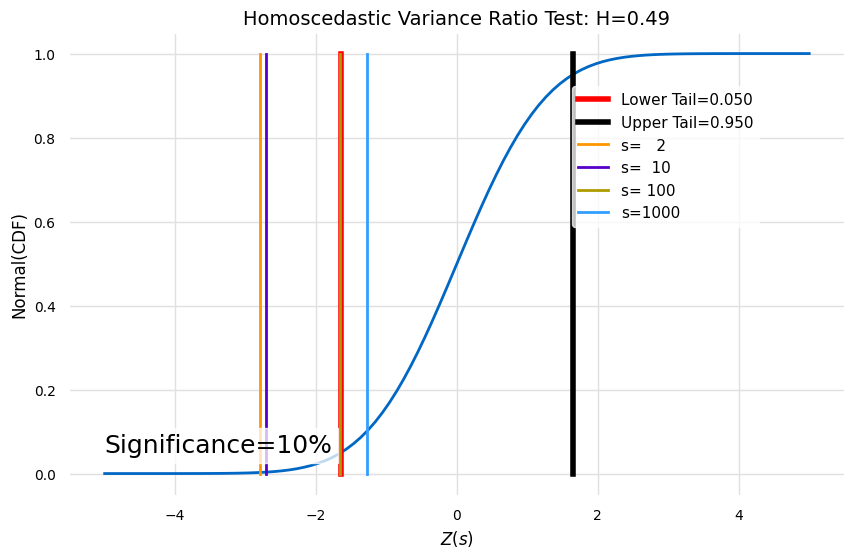

In [49]:
homo_test_stat_plot(result, H_vals[1])

In [50]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -2.802 │    0.005 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -2.706 │    0.007 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -1.661 │    0.097 │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.274 │    0.203 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

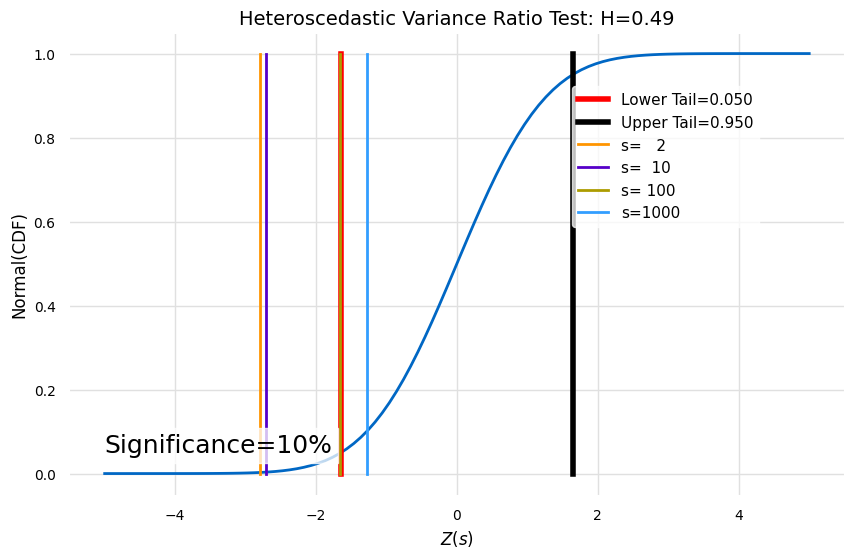

In [51]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.475

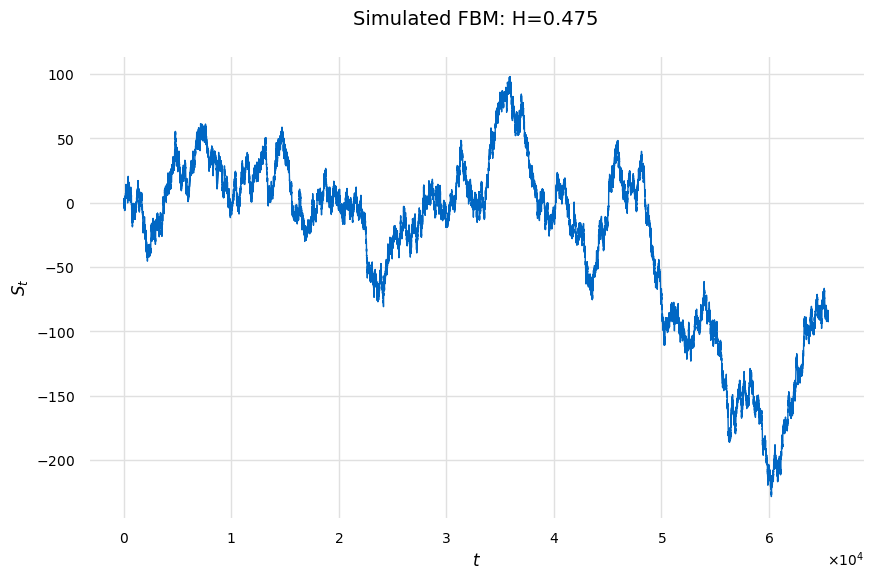

In [52]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [53]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -9.809 │     0    │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.099 │     0    │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -5.438 │     0    │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.514 │     0.13 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

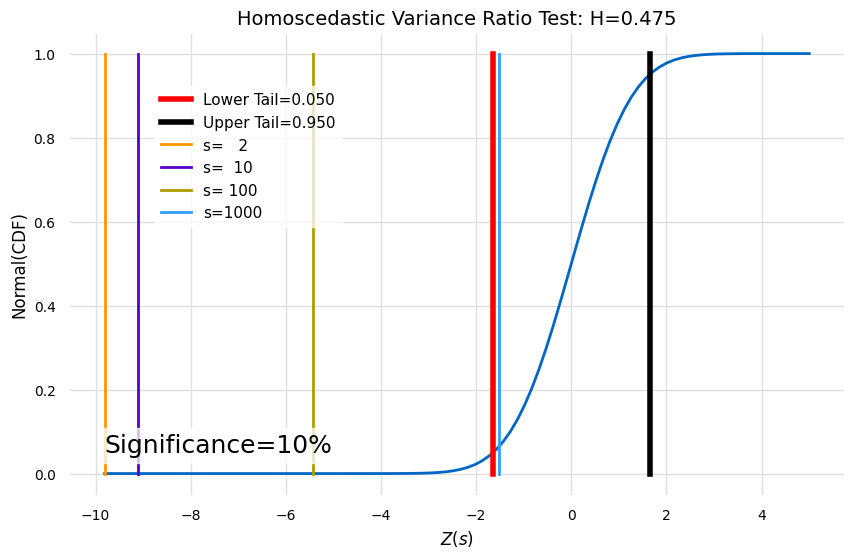

In [54]:
homo_test_stat_plot(result, H_vals[0])

In [55]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒══════╤════════╤══════════╤══════════╕
│    s │   Z(s) │   pvalue │ Result   │
╞══════╪════════╪══════════╪══════════╡
│    2 │ -9.899 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│   10 │ -9.118 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│  100 │ -5.443 │    0     │ Failed   │
├──────┼────────┼──────────┼──────────┤
│ 1000 │ -1.517 │    0.129 │ Passed   │
╘══════╧════════╧══════════╧══════════╛

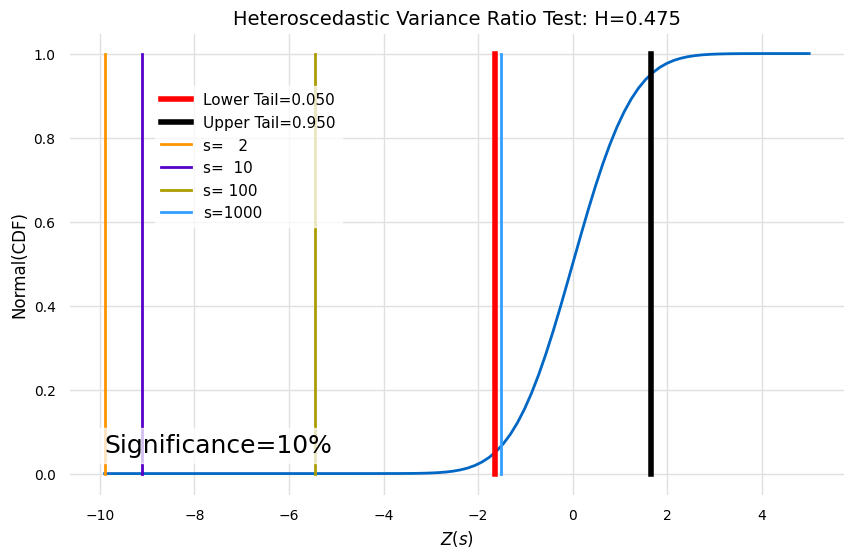

In [56]:
hetero_test_stat_plot(result, H_vals[0])

### Small Sample Size

In [57]:
npts = 2**9
s_vals = [4, 10, 25, 50, 100]
H_vals = [0.5, 0.7, 0.3]
t, samples = create(H_vals, npts)

#### H=0.5

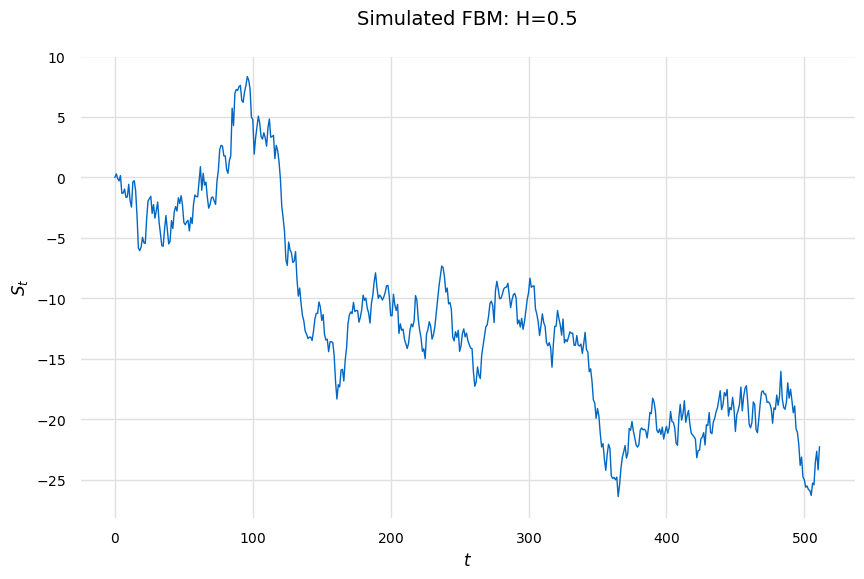

In [58]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [59]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.427 │    0.669 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.083 │    0.934 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.1   │    0.92  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.015 │    0.988 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -0

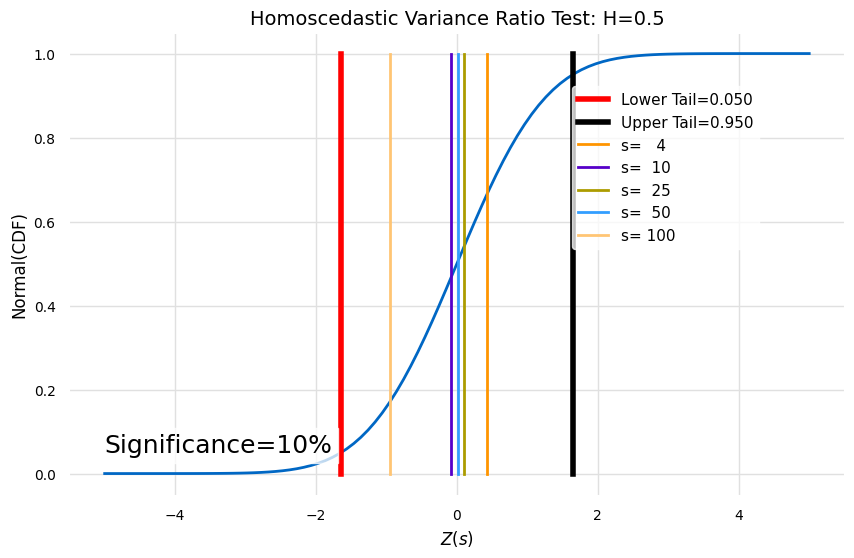

In [60]:
homo_test_stat_plot(result, H_vals[0])

In [61]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.425 │    0.671 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -0.084 │    0.933 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.102 │    0.918 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0.015 │    0.988 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -0

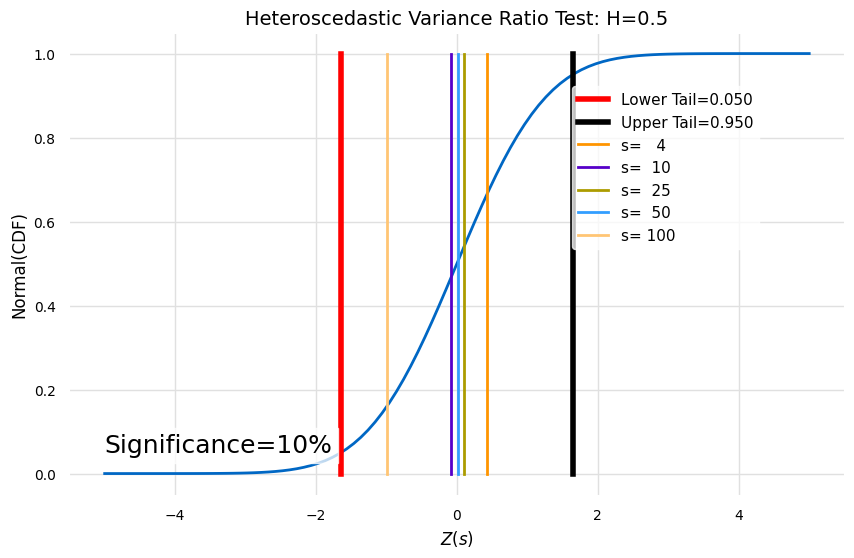

In [62]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.7

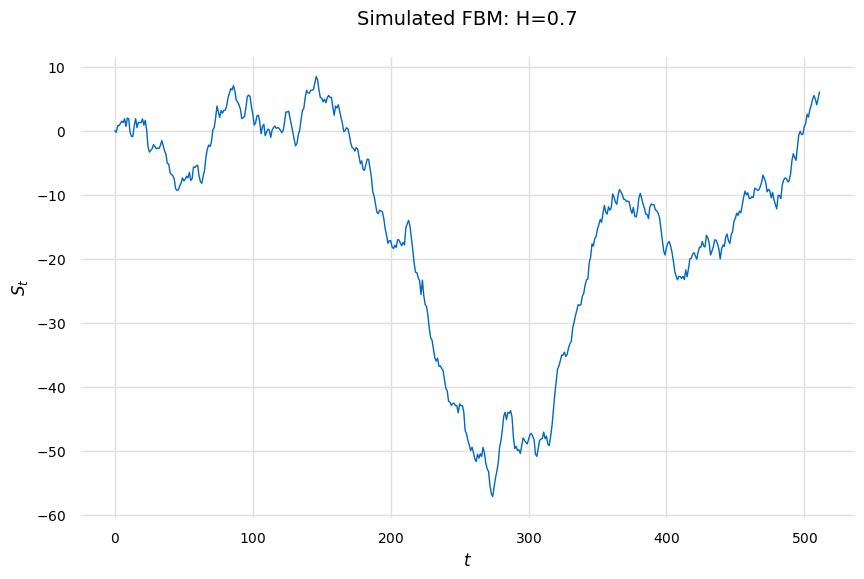

In [63]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [64]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  9.245 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  9.773 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 12.387 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 14.338 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ 14

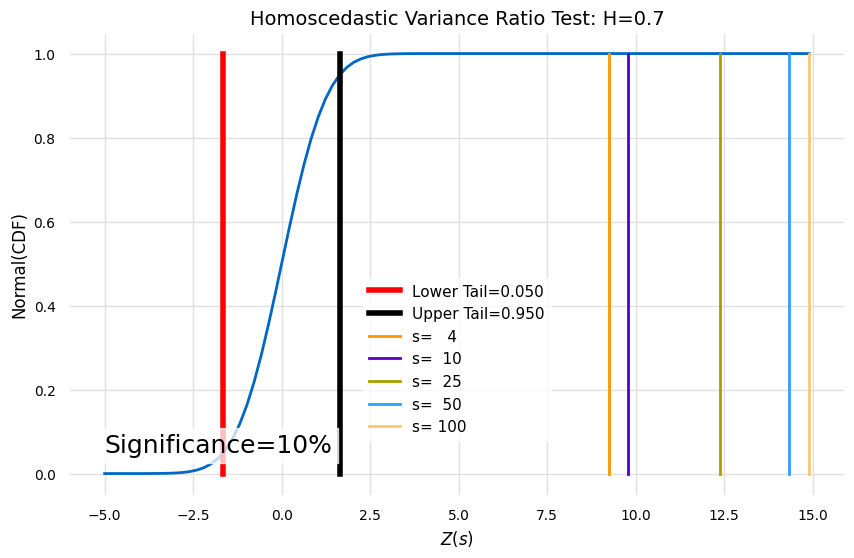

In [65]:
homo_test_stat_plot(result, H_vals[1])

In [66]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  8.569 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  9.379 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ 12.148 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ 14.322 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ 15

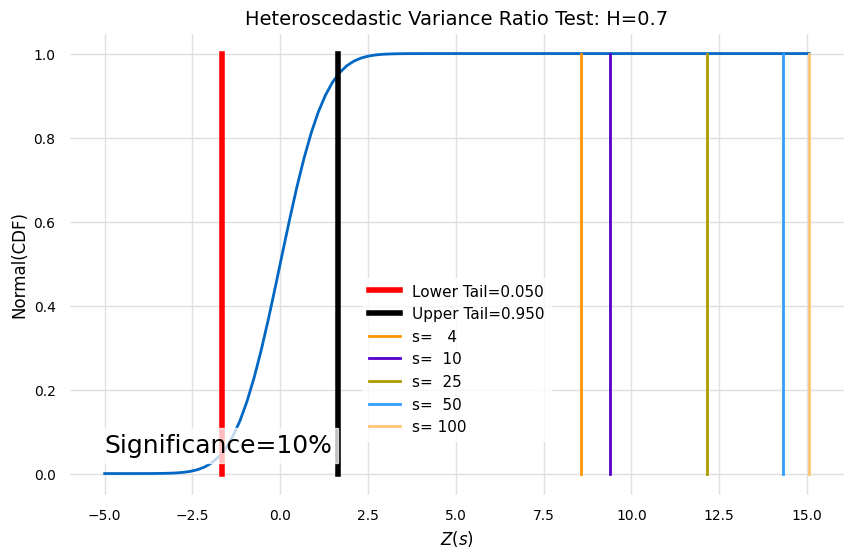

In [67]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.3

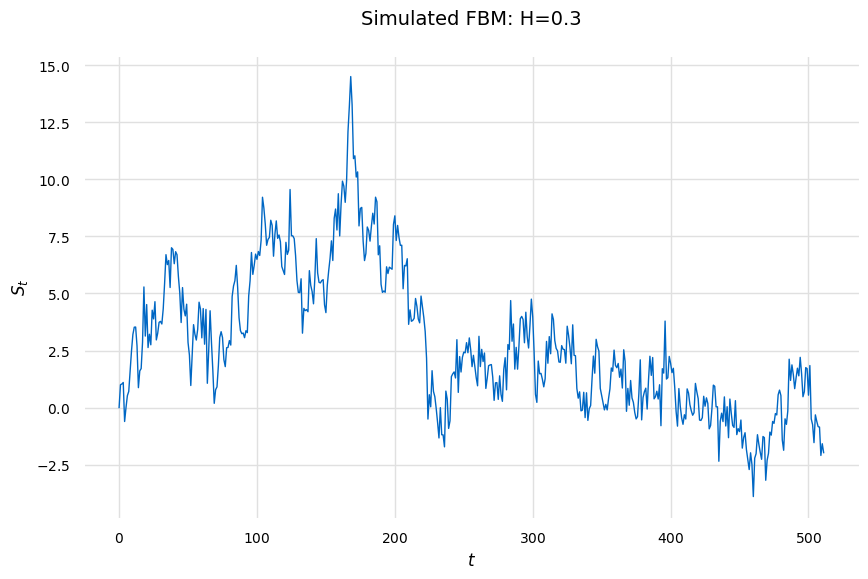

In [68]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [69]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.972 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.754 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.705 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.192 │    0.028 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

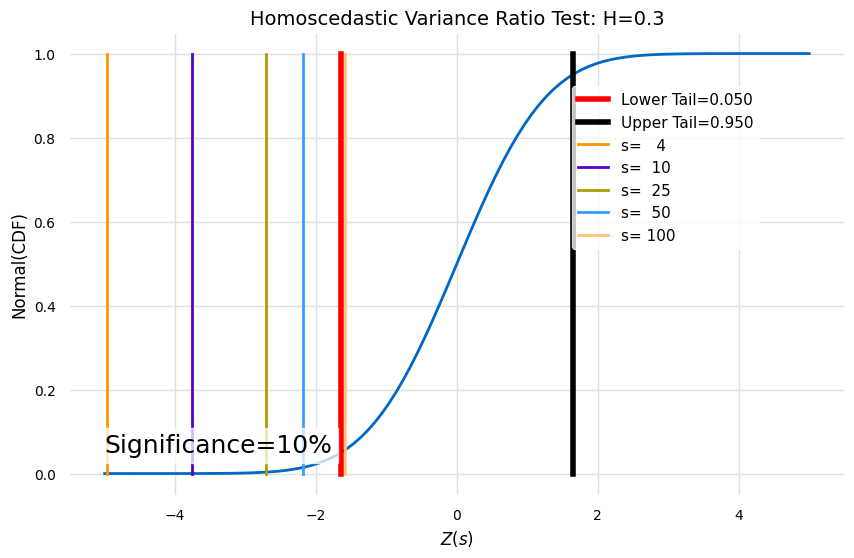

In [70]:
homo_test_stat_plot(result, H_vals[2])

In [71]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -4.685 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.643 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -2.698 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -2.224 │    0.026 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│ 100 │ -1

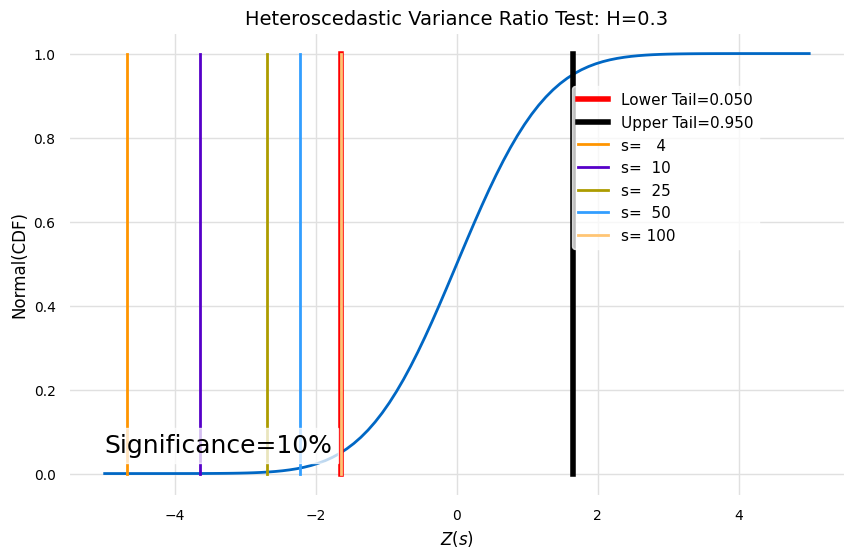

In [72]:
hetero_test_stat_plot(result, H_vals[2])

### Values Near H=0.5

In [73]:
npts = 2**9
s_vals = [2, 4, 10, 25, 50]
H_vals = [0.49, 0.45, 0.4, 0.51, 0.55]
t, samples = create(H_vals, npts)

#### H=0.49

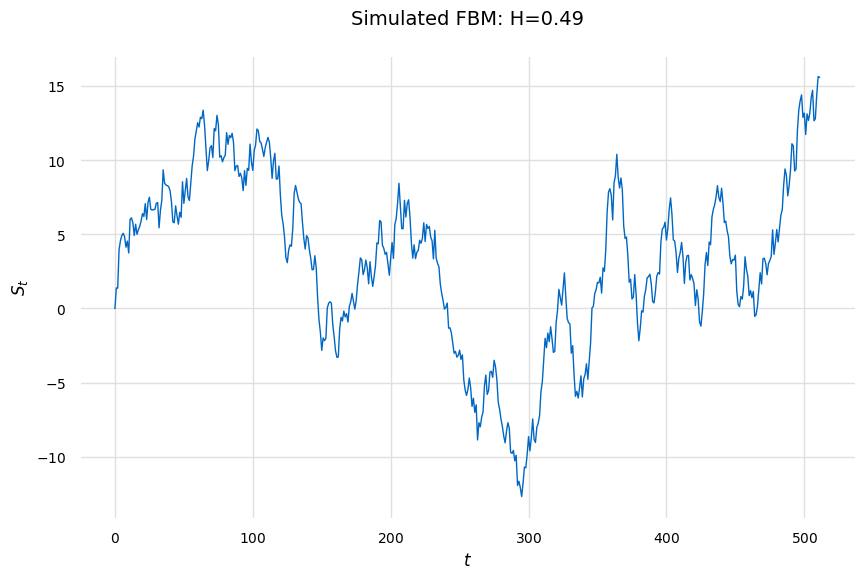

In [74]:
title = f"Simulated FBM: H={H_vals[0]}"
curve(samples[0], t[0], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [75]:
result, result_model = fbm.compute_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  1.251 │    0.211 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  1.17  │    0.242 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.413 │    0.158 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.851 │    0.395 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

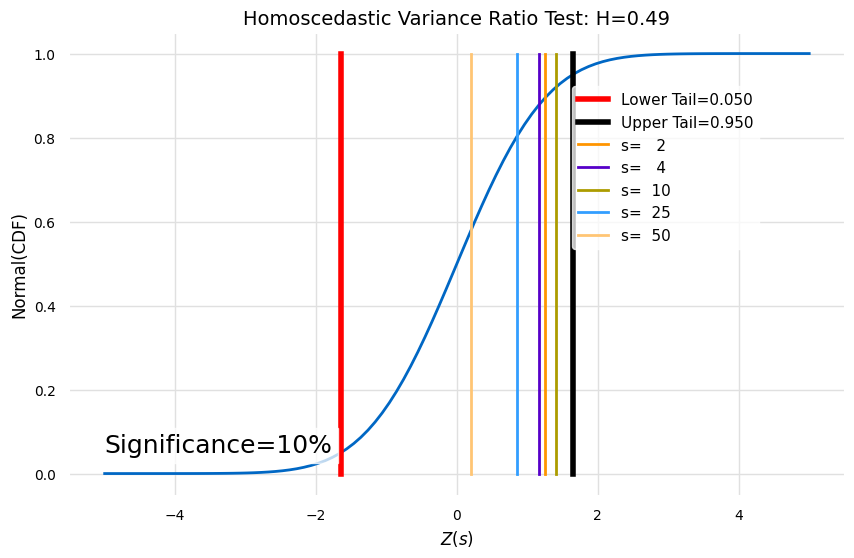

In [76]:
homo_test_stat_plot(result, H_vals[0])

In [77]:
result, result_model = fbm.compute_hetero_vr_test(samples[0], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  1.303 │    0.192 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  1.223 │    0.221 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  1.452 │    0.147 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.864 │    0.387 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

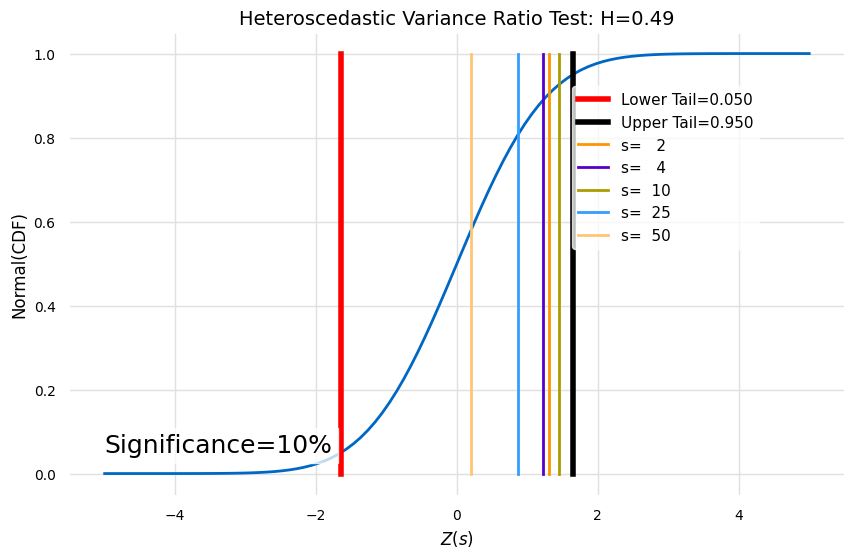

In [78]:
hetero_test_stat_plot(result, H_vals[0])

#### H=0.45

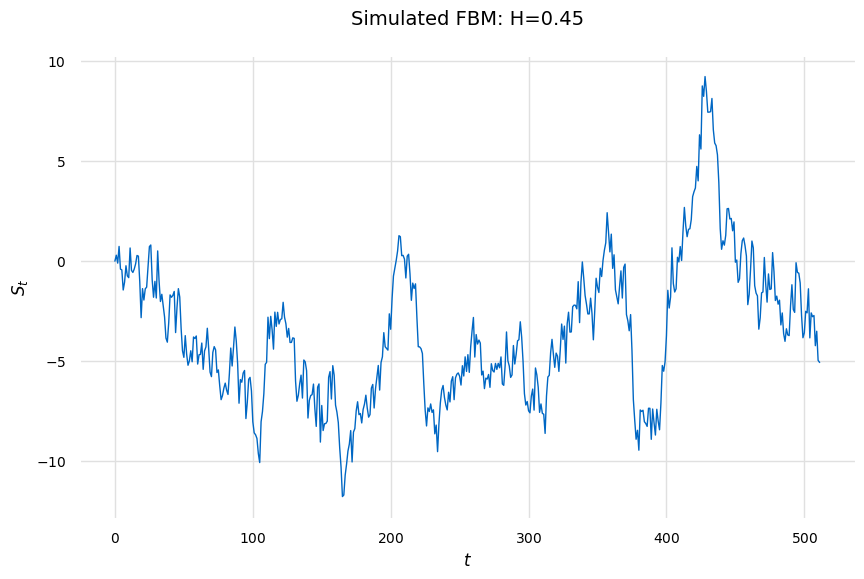

In [79]:
title = f"Simulated FBM: H={H_vals[1]}"
curve(samples[1], t[1], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [80]:
result, result_model = fbm.compute_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.862 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.672 │    0.008 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.467 │    0.142 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.76  │    0.447 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

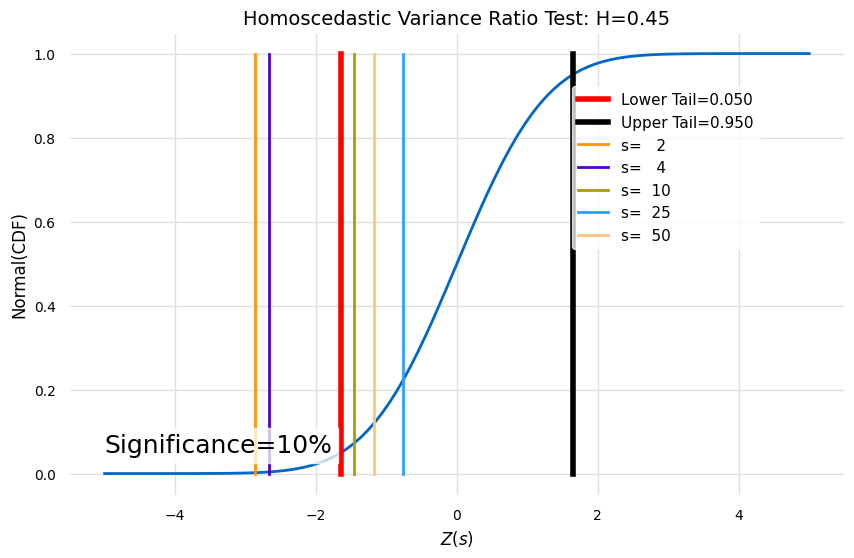

In [81]:
homo_test_stat_plot(result, H_vals[1])

In [82]:
result, result_model = fbm.compute_hetero_vr_test(samples[1], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -2.849 │    0.004 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.684 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -1.477 │    0.14  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.764 │    0.445 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -1

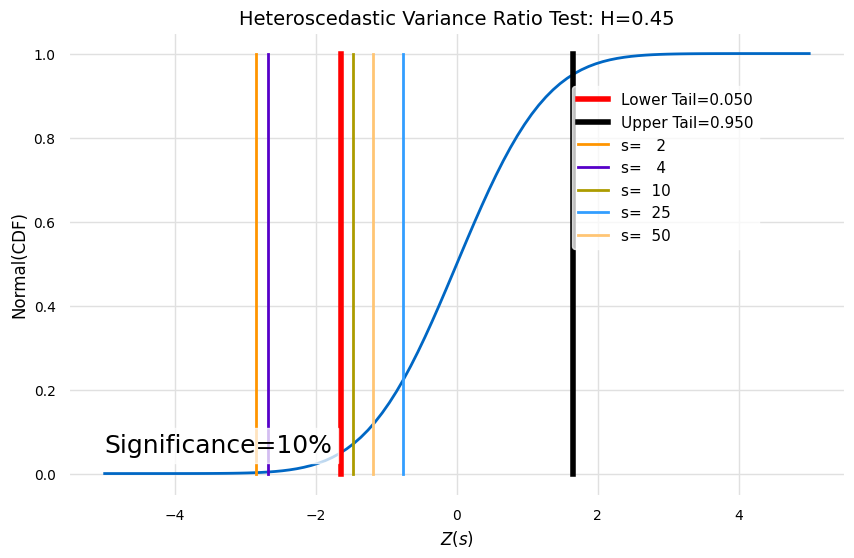

In [83]:
hetero_test_stat_plot(result, H_vals[1])

#### H=0.4

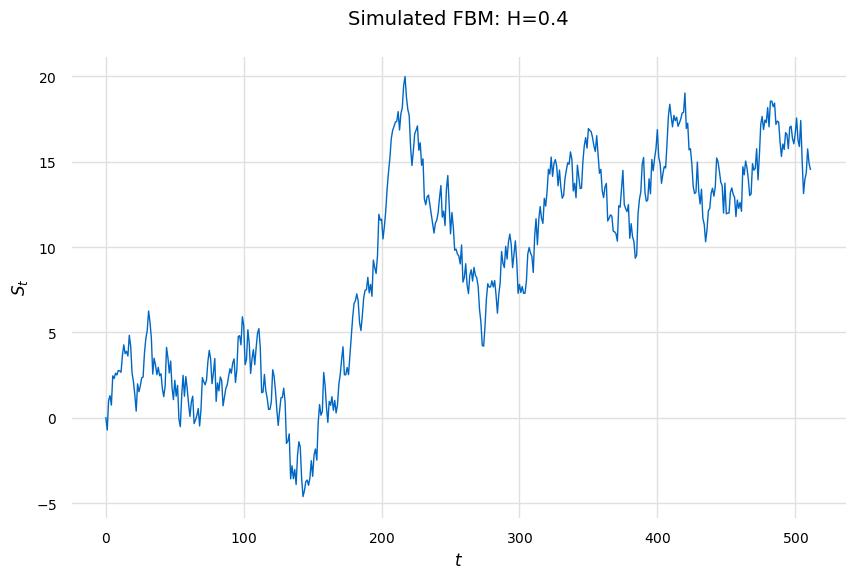

In [84]:
title = f"Simulated FBM: H={H_vals[2]}"
curve(samples[2], t[2], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [85]:
result, result_model = fbm.compute_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.605 │    0.109 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.504 │    0.012 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.055 │    0.04  │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.963 │    0.336 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

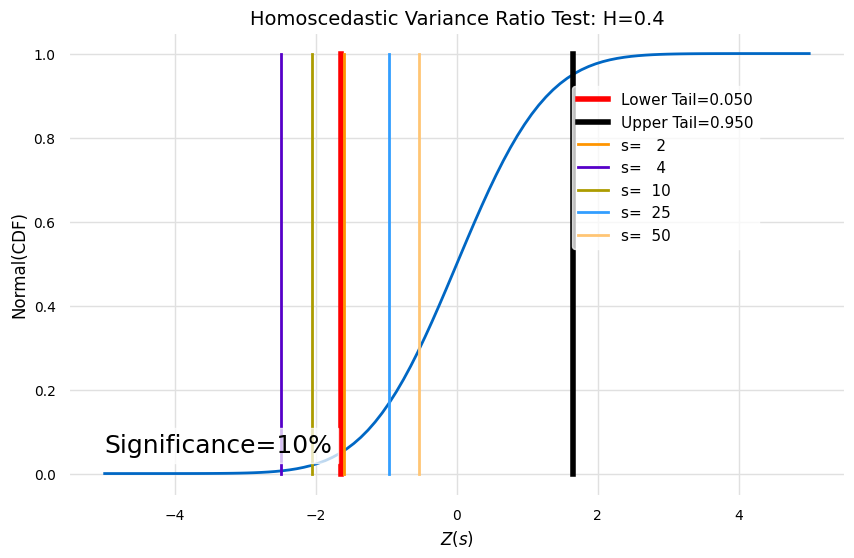

In [86]:
homo_test_stat_plot(result, H_vals[2])

In [87]:
result, result_model = fbm.compute_hetero_vr_test(samples[2], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │ -1.744 │    0.081 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │ -2.67  │    0.008 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -2.126 │    0.033 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │ -0.993 │    0.321 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │ -0

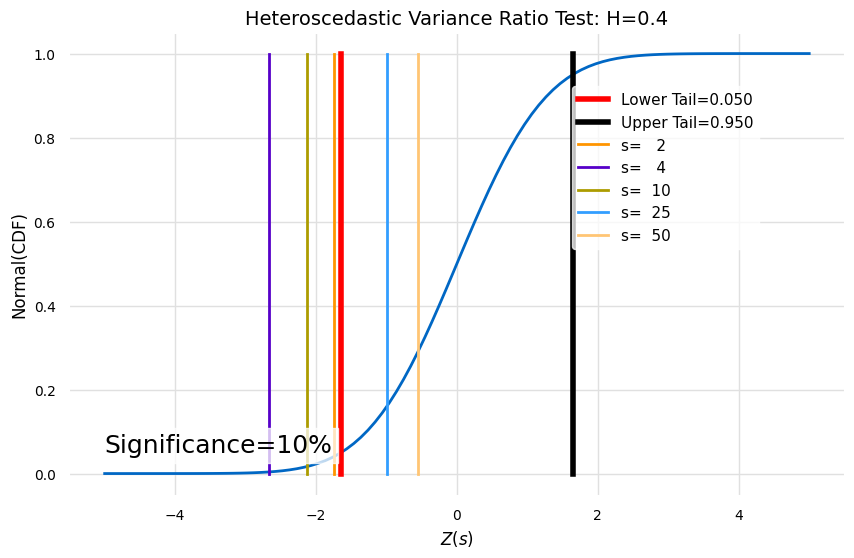

In [88]:
hetero_test_stat_plot(result, H_vals[2])

#### H=0.51

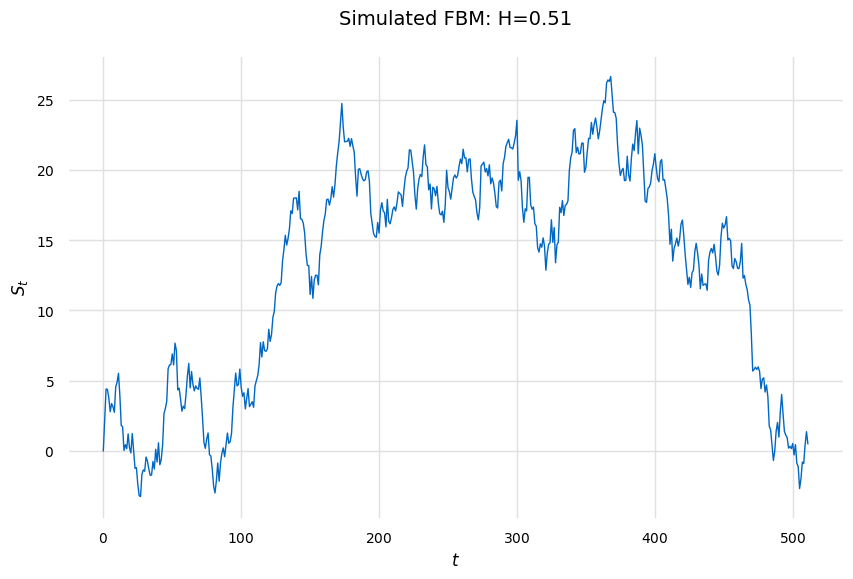

In [89]:
title = f"Simulated FBM: H={H_vals[3]}"
curve(samples[3], t[3], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [90]:
result, result_model = fbm.compute_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.239 │    0.811 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.918 │    0.359 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.529 │    0.597 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.654 │    0.513 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

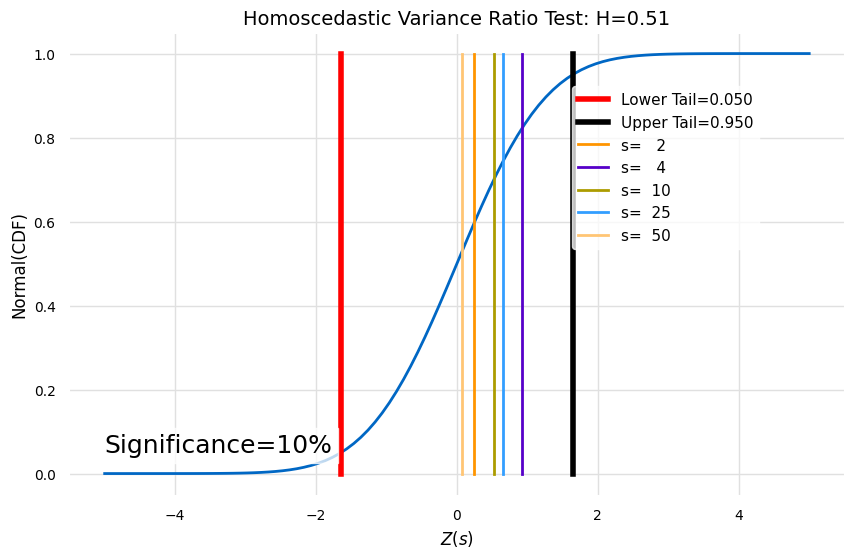

In [91]:
homo_test_stat_plot(result, H_vals[3])

In [92]:
result, result_model = fbm.compute_hetero_vr_test(samples[3], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  0.244 │    0.807 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  0.949 │    0.343 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.55  │    0.582 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  0.675 │    0.5   │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  0

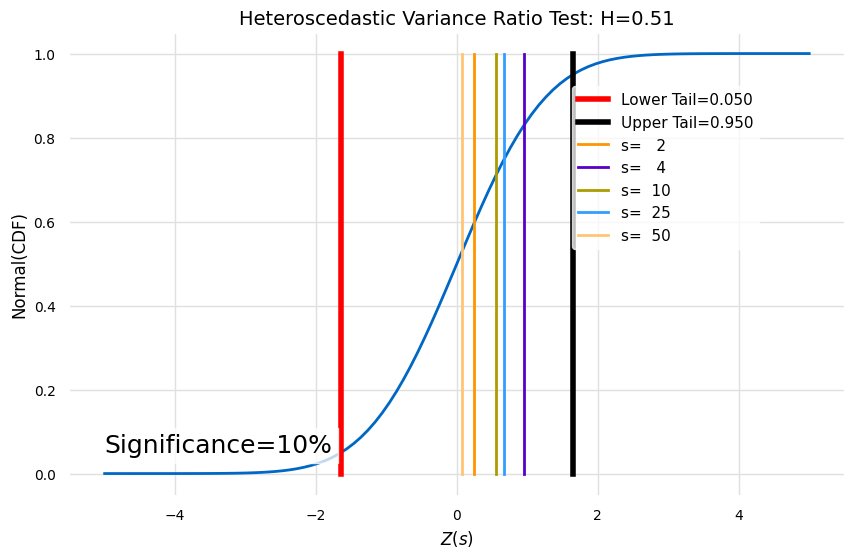

In [93]:
hetero_test_stat_plot(result, H_vals[3])

#### H=0.55

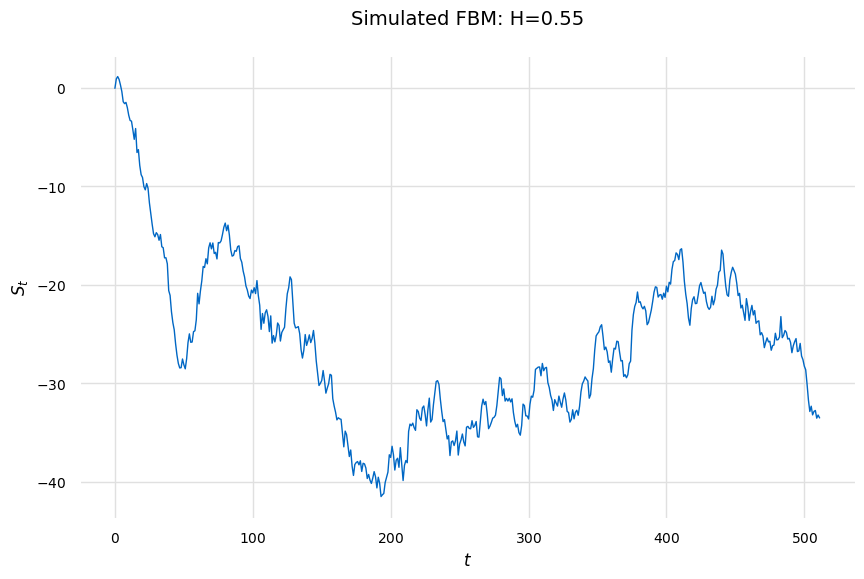

In [94]:
title = f"Simulated FBM: H={H_vals[4]}"
curve(samples[4], t[4], title=title, xlabel=r"$t$", ylabel=r"$S_t$", lw=1)

In [95]:
result, result_model = fbm.compute_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  2.206 │    0.027 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  3.117 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.711 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.754 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

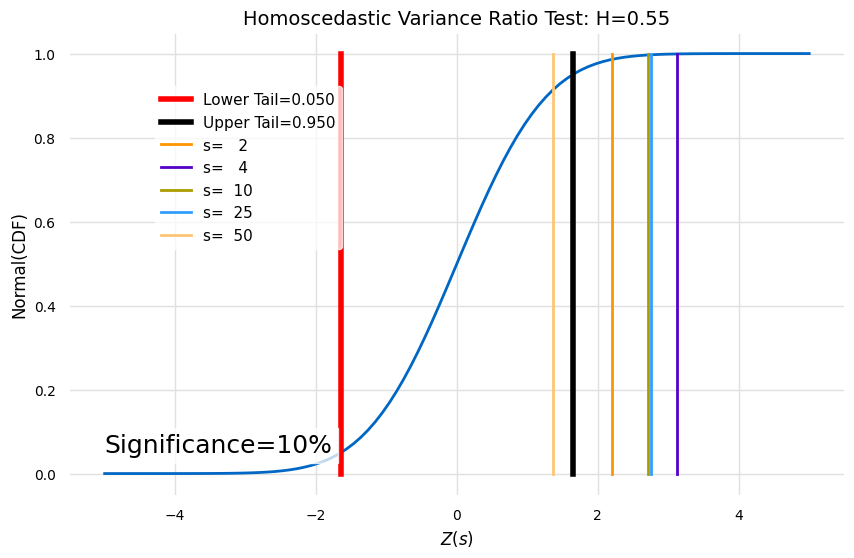

In [96]:
homo_test_stat_plot(result, H_vals[4])

In [97]:
result, result_model = fbm.compute_hetero_vr_test(samples[4], HypothesisTestType.BM, s=s_vals)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   2 │  2.127 │    0.033 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   4 │  3.043 │    0.002 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  2.684 │    0.007 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  25 │  2.743 │    0.006 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  50 │  1

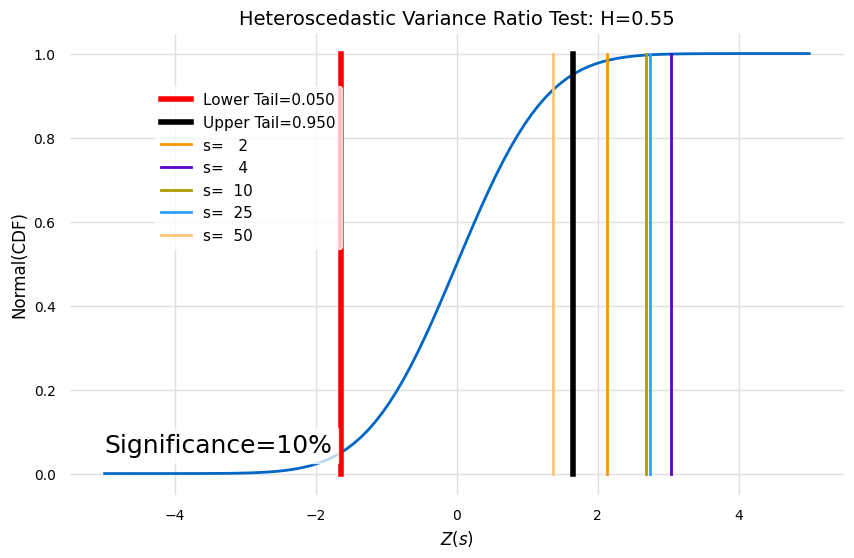

In [98]:
hetero_test_stat_plot(result, H_vals[4])

## Variance Ratio Test

Here the performance of the variance ratio test is evaluated. In the previous analysis the performance of the homoscedastic test was not significantly different</br>
than the heteroscedastic test. Since the homoscedastic test is much faster it is used. The values of the variance ratio test statistic for $0 < H < \frac{1}{2}$, $H=\frac{1}{2}$</br>
and $\frac{1}{2} < H < 1$ respectively satisfy $Z(s) < 0$, $Z(s) = 0$ and $Z(s) > 0$. This follows from the variance ratio, $\text{VR}(s)$ satisfying $0 < \text{VR}(s) < 1$, $\text{VR}(s)=1$ and $\text{VR}(s) > 1$</br>
in that same regions. Plots of $Z(s)$ for these regions are shown below. It is seen for $0 < H < \frac{1}{2}$ that $Z(s)$ is an increasing function of $s$ and for $\frac{1}{2} < H < 1$</br>
$Z(s)$ has a more complex behavior but is increasing for smaller values of $s$. It follows that eventually for some value of $s$ the test will likely fail. This makes interpreting the tests</br> 
results somewhat difficult. In the previous analysis where $\text{VR}(s)$ was compared to $\sigma s^{2H-1}$ it was seen that for a series with $2^9$ points the the two values agreed well for</br>
up to $s=2^8$. This motivates evaluating $Z(s)$ in regions where it is always increasing using a sequence of values of $s$ satisfying $s \le 25$. For this range the agreement between $\text{VR}(s)$</br>
and $\sigma s^{2H-1}$ was best. $Z(s)$ is evaluated for each $s$ and the result is pass if at least one test passes and failed otherwise.

### $H \le \frac{1}{2}$

In [99]:
npts = 2**9
s_min=2.0
s_max=npts/2
s_npts=int(s_max - s_min + 1)

In [100]:
H_vals = [0.1, 0.2, 0.3, 0.4, 0.5]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

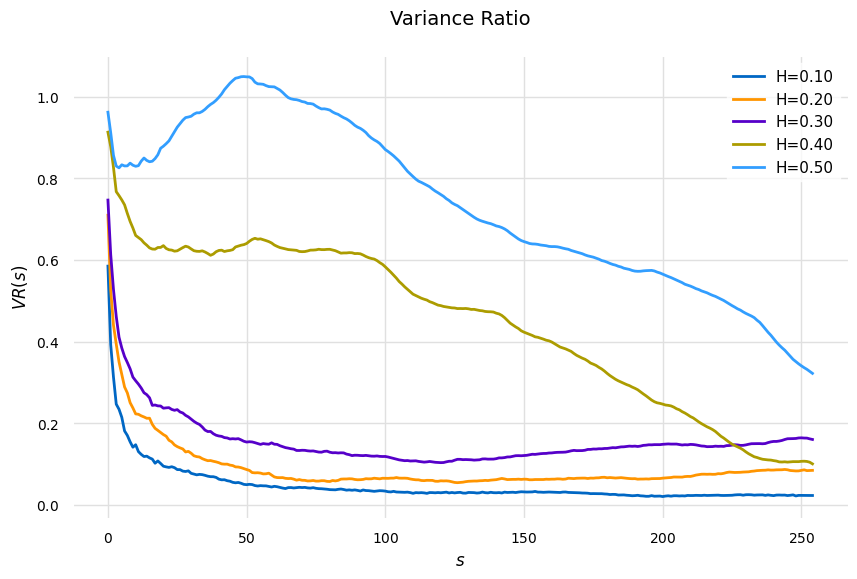

In [101]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H \ge \frac{1}{2}$

In [102]:
H_vals = [0.5, 0.6, 0.7, 0.8, 0.89]
t, samples = create(H_vals, npts)
func = lambda t, data, **kwargs: fbm.compute_vr_scan(data, **kwargs)
_, vr = apply_to_parameter_scan(func, t, samples, smin=s_min, smax=s_max, npts=s_npts, linear=True)

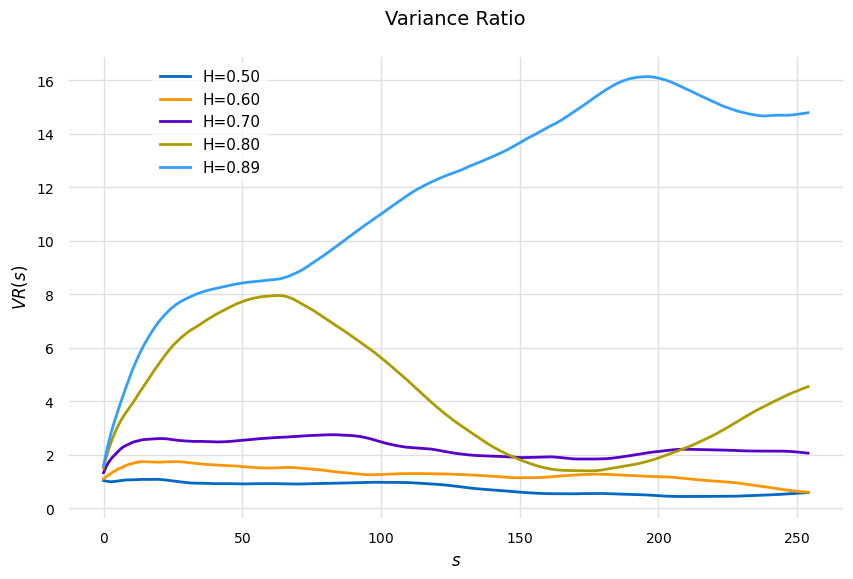

In [103]:
title = r"Variance Ratio"
comparison(vr, title=title, labels=H_labels(H_vals), xlabel=r"$s$", ylabel=r"$VR(s)$")

### $H = 0.5$

Here a two tailed test for brownian motion is performed. This test is successful if the result is **PASSED**

In [104]:
H=0.5
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.04  │    0.968 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.067 │    0.947 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.554 │    0.58  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.895 │    0.371 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  1

In [105]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "2e674622-507b-436b-b491-d7fff2e90ec4",
                "label": "$Z(s)$",
                "value": 0.04033974066233855
            },
            "pval": {
                "test_id": "2e674622-507b-436b-b491-d7fff2e90ec4",
                "label": "$p-value$",
                "value": 0.9678222710831497
            },
            "params": [
                {
                    "test_id": "2e674622-507b-436b-b491-d7fff2e90ec4",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "2e674622-507b-436b-b491-d7fff2e90ec4",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "2e674622-507b-436b-b491-d7fff2e90ec4",
                "labe

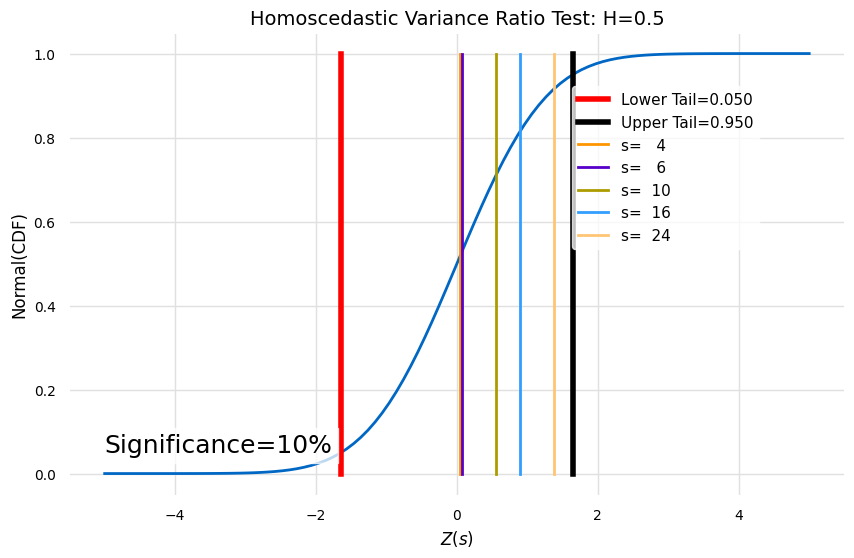

In [106]:
homo_test_stat_plot(result, H)

In [107]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.04  │    0.484 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.067 │    0.473 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.554 │    0.29  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.895 │    0.186 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  1.378 │    0.084 │ Fai

In [108]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "fbdee786-5ab7-4e78-8103-cec60444ef6f",
                "label": "$Z(s)$",
                "value": 0.04033974066233855
            },
            "pval": {
                "test_id": "fbdee786-5ab7-4e78-8103-cec60444ef6f",
                "label": "$p-value$",
                "value": 0.48391113554157483
            },
            "params": [
                {
                    "test_id": "fbdee786-5ab7-4e78-8103-cec60444ef6f",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "fbdee786-5ab7-4e78-8103-cec60444ef6f",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "fbdee786-5ab7-4e78-8103

In [109]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  0.04  │    0.516 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  0.067 │    0.527 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  0.554 │    0.71  │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  0.895 │    0.814 │ Passed   │
├─────┼────────┼──────────┼───────

In [110]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "31e92a83-d06f-4a58-8880-2da89d295418",
                "label": "$Z(s)$",
                "value": 0.04033974066233855
            },
            "pval": {
                "test_id": "31e92a83-d06f-4a58-8880-2da89d295418",
                "label": "$p-value$",
                "value": 0.5160888644584252
            },
            "params": [
                {
                    "test_id": "31e92a83-d06f-4a58-8880-2da89d295418",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "31e92a83-d06f-4a58-8880-2da89d295418",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "31e92a83-d06f-4a58-8880-2da89d295418",
        

### $H = 0.35$

Here a lower tail test is performed for fractional brownian with $H<\frac{1}{2}$. The test is successful if the result is **Failed**.

In [111]:
H=0.35
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -5.164 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.433 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.914 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.618 │    0     │ Failed   │
├─────┼────────┼──────────┼───────

In [112]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "8fcdc31a-3683-43aa-b31c-5bac6c53cb2e",
                "label": "$Z(s)$",
                "value": -5.164174954826862
            },
            "pval": {
                "test_id": "8fcdc31a-3683-43aa-b31c-5bac6c53cb2e",
                "label": "$p-value$",
                "value": 1.2075086882900718e-07
            },
            "params": [
                {
                    "test_id": "8fcdc31a-3683-43aa-b31c-5bac6c53cb2e",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "8fcdc31a-3683-43aa-b31c-5bac6c53cb2e",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "8fcdc31a-3683-43aa-b31c-5bac6c53cb2e",
     

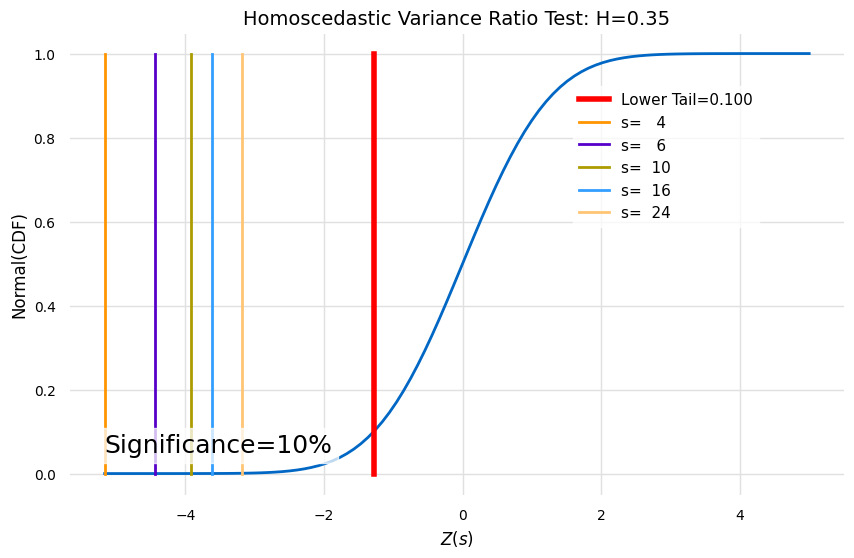

In [113]:
homo_test_stat_plot(result, H)

In [114]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -5.164 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.433 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.914 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.618 │    1     │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -3.187 │    0.999 │ Pas

In [115]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "881210ed-ff08-4de9-830b-f363861b283a",
                "label": "$Z(s)$",
                "value": -5.164174954826862
            },
            "pval": {
                "test_id": "881210ed-ff08-4de9-830b-f363861b283a",
                "label": "$p-value$",
                "value": 0.9999998792491311
            },
            "params": [
                {
                    "test_id": "881210ed-ff08-4de9-830b-f363861b283a",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "881210ed-ff08-4de9-830b-f363861b283a",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "881210ed-ff08-4de9-830b-f

In [116]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │ -5.164 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │ -4.433 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │ -3.914 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │ -3.618 │    0     │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │ -3

In [117]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "26dd4ae3-1341-4758-980a-c9719963c300",
                "label": "$Z(s)$",
                "value": -5.164174954826862
            },
            "pval": {
                "test_id": "26dd4ae3-1341-4758-980a-c9719963c300",
                "label": "$p-value$",
                "value": 2.415017377188633e-07
            },
            "params": [
                {
                    "test_id": "26dd4ae3-1341-4758-980a-c9719963c300",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "26dd4ae3-1341-4758-980a-c9719963c300",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "26dd4ae3-1341-4758-980a-c9719963c300",
                "la

### $H = 0.6$

Here an upper tailed test for fractional brownian motion with $H > \frac{1}{2}$. The test is successful if the result is **Failed**.

In [118]:
H=0.6
t, samples = fbm.create_fft_source(H=H, npts=npts)
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.UPPER_TAIL        │
├──────────────────────┼──────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_AUTO_CORR │
├──────────────────────┼──────────────────────────────────┤
│ Significance         │ 10%                              │
├──────────────────────┼──────────────────────────────────┤
│ Upper Critical Value │ 1.282                            │
╘══════════════════════╧══════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.001 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.572 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.645 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  5.245 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  5.781 │        0 │ Fai

In [119]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "UPPER_TAIL",
    "hyp_test_type": "AUTO_CORR",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "fd22d063-9e3e-4171-9ef3-caa6427ad569",
                "label": "$Z(s)$",
                "value": 5.000715980280395
            },
            "pval": {
                "test_id": "fd22d063-9e3e-4171-9ef3-caa6427ad569",
                "label": "$p-value$",
                "value": 2.8558901321584784e-07
            },
            "params": [
                {
                    "test_id": "fd22d063-9e3e-4171-9ef3-caa6427ad569",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "fd22d063-9e3e-4171-9ef3-caa6427ad569",
                "label": "10%",
                "value": 0.1
            },
            "lower": null,
            "upper": {
                "test_id": "fd22d063-9e3e-4171-9ef

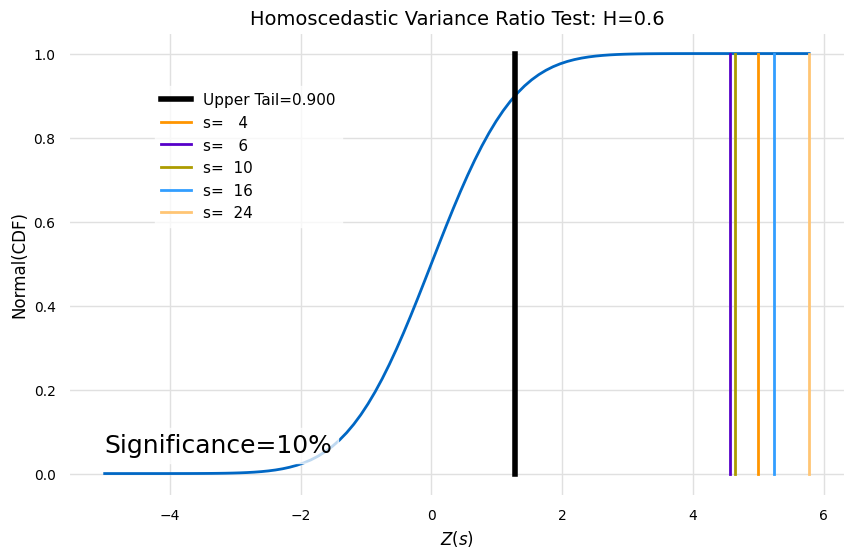

In [120]:
homo_test_stat_plot(result, H)

In [121]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.FBM_NEG_AUTO_CORR)
result.summary()

╒══════════════════════╤══════════════════════════════════════╕
│ Hypothesis Type      │ HypothesisType.LOWER_TAIL            │
├──────────────────────┼──────────────────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.FBM_NEG_AUTO_CORR │
├──────────────────────┼──────────────────────────────────────┤
│ Significance         │ 10%                                  │
├──────────────────────┼──────────────────────────────────────┤
│ Lower Critical Value │ -1.282                               │
╘══════════════════════╧══════════════════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.001 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.572 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.645 │        1 │ Passed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  5.245 │        1 │ Passed   │
├─────┼────────┼──────────┼───────

In [122]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "NEG_AUTO_CORR",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "6c519b0c-5050-4cf7-b05d-ae3e6ab29035",
                "label": "$Z(s)$",
                "value": 5.000715980280395
            },
            "pval": {
                "test_id": "6c519b0c-5050-4cf7-b05d-ae3e6ab29035",
                "label": "$p-value$",
                "value": 0.9999997144109868
            },
            "params": [
                {
                    "test_id": "6c519b0c-5050-4cf7-b05d-ae3e6ab29035",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "6c519b0c-5050-4cf7-b05d-ae3e6ab29035",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "6c519b0c-5050-4cf7-b05d-ae3e6ab29035",
          

In [123]:
result, result_model = fbm.compute_vr_test(samples, HypothesisTestType.BM)
result.summary()

╒══════════════════════╤═════════════════════════╕
│ Hypothesis Type      │ HypothesisType.TWO_TAIL │
├──────────────────────┼─────────────────────────┤
│ Hypothesis Test Type │ HypothesisTestType.BM   │
├──────────────────────┼─────────────────────────┤
│ Significance         │ 10%                     │
├──────────────────────┼─────────────────────────┤
│ Lower Critical Value │ -1.645                  │
├──────────────────────┼─────────────────────────┤
│ Upper Critical Value │ 1.645                   │
╘══════════════════════╧═════════════════════════╛
╒═════╤════════╤══════════╤══════════╕
│   s │   Z(s) │   pvalue │ Result   │
╞═════╪════════╪══════════╪══════════╡
│   4 │  5.001 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│   6 │  4.572 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  10 │  4.645 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  16 │  5.245 │        0 │ Failed   │
├─────┼────────┼──────────┼──────────┤
│  24 │  5

In [124]:
print(result_model.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "TWO_TAIL",
    "hyp_test_type": "BM",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "27eada8d-c147-40e8-b88f-0bc994a7e1bd",
                "label": "$Z(s)$",
                "value": 5.000715980280395
            },
            "pval": {
                "test_id": "27eada8d-c147-40e8-b88f-0bc994a7e1bd",
                "label": "$p-value$",
                "value": 5.711780264316957e-07
            },
            "params": [
                {
                    "test_id": "27eada8d-c147-40e8-b88f-0bc994a7e1bd",
                    "label": "$s$",
                    "value": 4
                }
            ],
            "sig": {
                "test_id": "27eada8d-c147-40e8-b88f-0bc994a7e1bd",
                "label": "10%",
                "value": 0.1
            },
            "lower": {
                "test_id": "27eada8d-c147-40e8-b88f-0bc994a7e1bd",
                "lab